# MARS Controlled Feature-Extraction Benchmark

This notebook provides a controlled framework for comparing image feature-extraction methods.

## Current benchmark

The current experiment compares feature extractors on the first ten subjects of the FEI facial-image dataset using:

- identical image preprocessing;
- a fixed stratified training, validation and held-out test split;
- a common feature-standardisation procedure;
- a common linear SVM classifier;
- validation-only method development;
- and a locked test set until final model selection.

The current methods are:

1. Handcrafted eight-feature extractor;
2. Original Genetic Programming;
3. Modified Genetic Programming;
4. Evolution of Heuristics eight-feature extractor.

The final controlled comparison will use exactly eight features per method.

## Future extension

After the four-method comparison and robustness analysis are complete, the same framework will be extended to noisier datasets, video frames and live camera data.

In [1]:
from pathlib import Path
from typing import Any, Callable

import importlib
import inspect
import json
import pickle
import random
import re
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from skimage import color, io, transform
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [2]:
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

EXPERIMENT_NAME = "mars_fei_controlled_benchmark"
DATASET_NAME = "FEI_part1_first_10_subjects"
DATA_SOURCE_TYPE = "static_image_directory"

IMAGE_SIZE = (64, 64)
SELECTED_SUBJECTS = tuple(range(1, 11))
EXPECTED_IMAGES_PER_SUBJECT = 14
EXPECTED_SELECTED_IMAGE_COUNT = len(SELECTED_SUBJECTS) * EXPECTED_IMAGES_PER_SUBJECT

TEST_SIZE = 0.20
VALIDATION_SIZE_WITHIN_DEVELOPMENT = 0.25

N_FEATURES = 8
SVM_KERNEL = "linear"
SVM_C = 1.0
LOCK_TEST_SET = True

print("=" * 70)
print("Experiment configuration")
print("=" * 70)
print(f"Experiment name   : {EXPERIMENT_NAME}")
print(f"Dataset           : {DATASET_NAME}")
print(f"Selected subjects : {SELECTED_SUBJECTS}")
print(f"Image size        : {IMAGE_SIZE}")
print(f"Target features   : {N_FEATURES}")
print(f"Random state      : {RANDOM_STATE}")
print(f"Test set locked   : {LOCK_TEST_SET}")
print("=" * 70)

Experiment configuration
Experiment name   : mars_fei_controlled_benchmark
Dataset           : FEI_part1_first_10_subjects
Selected subjects : (1, 2, 3, 4, 5, 6, 7, 8, 9, 10)
Image size        : (64, 64)
Target features   : 8
Random state      : 42
Test set locked   : True


In [3]:
def find_project_root(start: Path | None = None) -> Path:
    """Locate the repository root without relying on a machine-specific path."""
    current = Path(start or Path.cwd()).resolve()

    for candidate in (current, *current.parents):
        if (candidate / "src" / "config.py").exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate the MARS-Summer-Research repository root. "
        "Run this notebook from somewhere inside the cloned repository."
    )


PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import FEI_DIR, RESULTS_DIR as PROJECT_RESULTS_DIR

DATASET_DIR = FEI_DIR

OUTPUTS_DIR = PROJECT_RESULTS_DIR / "fei_benchmark"
RESULTS_DIR = OUTPUTS_DIR / "benchmark_results"
FIGURES_DIR = OUTPUTS_DIR / "benchmark_figures"
PROGRAMS_DIR = OUTPUTS_DIR / "selected_programs"
CHECKPOINTS_DIR = OUTPUTS_DIR / "checkpoints"

if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f"FEI dataset directory does not exist:\n{DATASET_DIR}\n"
        "Place the raw FEI images in data/raw/FEI/."
    )

for directory in [RESULTS_DIR, FIGURES_DIR, PROGRAMS_DIR, CHECKPOINTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("Project paths")
print("=" * 70)
print(f"Project root       : {PROJECT_ROOT}")
print(f"Dataset directory  : {DATASET_DIR}")
print(f"Results directory  : {RESULTS_DIR}")
print(f"Figures directory  : {FIGURES_DIR}")
print(f"Programs directory : {PROGRAMS_DIR}")
print(f"Checkpoints        : {CHECKPOINTS_DIR}")
print("=" * 70)


Project paths
Project root       : <PROJECT_ROOT>
Dataset directory  : <PROJECT_ROOT>\data\raw\FEI
Results directory  : <PROJECT_ROOT>\results\fei_benchmark\benchmark_results
Figures directory  : <PROJECT_ROOT>\results\fei_benchmark\benchmark_figures
Programs directory : <PROJECT_ROOT>\results\fei_benchmark\selected_programs
Checkpoints        : <PROJECT_ROOT>\results\fei_benchmark\checkpoints


# 1. Dataset Discovery and Preprocessing

FEI-specific filename parsing is kept separate from general image preprocessing so the same preprocessing function can later accept noisy images, video frames and live camera frames.

In [4]:
SUPPORTED_IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png"}

def discover_image_files(directory: Path) -> list[Path]:
    directory = Path(directory).resolve()

    if not directory.exists():
        raise FileNotFoundError(f"Image directory does not exist:\n{directory}")

    if not directory.is_dir():
        raise NotADirectoryError(f"Expected a directory:\n{directory}")

    paths = sorted(
        path for path in directory.iterdir()
        if path.is_file() and path.suffix.lower() in SUPPORTED_IMAGE_SUFFIXES
    )

    if not paths:
        raise FileNotFoundError(f"No supported images were found in:\n{directory}")

    return paths

def parse_fei_filename(image_path: Path) -> tuple[int, int]:
    parts = image_path.stem.split("-")
    if len(parts) != 2:
        raise ValueError(
            f"Unexpected FEI filename: {image_path.name}. "
            "Expected '<subject>-<image>'."
        )

    try:
        subject_id = int(parts[0])
        image_number = int(parts[1])
    except ValueError as error:
        raise ValueError(f"Could not parse {image_path.name}") from error

    if subject_id < 1 or image_number < 1:
        raise ValueError(f"Invalid FEI identifiers in {image_path.name}")

    return subject_id, image_number

all_image_paths = discover_image_files(DATASET_DIR)
print(f"Image files found: {len(all_image_paths)}")


Image files found: 700


In [5]:
records = []

for image_path in all_image_paths:
    subject_id, image_number = parse_fei_filename(image_path)
    records.append(
        {
            "filename": image_path.name,
            "filepath": image_path,
            "subject_id": subject_id,
            "image_number": image_number,
            "label": subject_id - 1,
        }
    )

fei_metadata = (
    pd.DataFrame(records)
    .sort_values(["subject_id", "image_number"])
    .reset_index(drop=True)
)

subject_counts = fei_metadata.groupby("subject_id").size()

if len(fei_metadata) != 700:
    raise ValueError(f"Expected 700 FEI images, found {len(fei_metadata)}.")

if fei_metadata["subject_id"].nunique() != 50:
    raise ValueError("Expected 50 FEI subjects.")

if not (subject_counts == EXPECTED_IMAGES_PER_SUBJECT).all():
    raise ValueError("Every FEI subject should have 14 images.")

benchmark_metadata = (
    fei_metadata[fei_metadata["subject_id"].isin(SELECTED_SUBJECTS)]
    .copy()
    .reset_index(drop=True)
)

if len(benchmark_metadata) != EXPECTED_SELECTED_IMAGE_COUNT:
    raise ValueError(
        f"Expected {EXPECTED_SELECTED_IMAGE_COUNT} selected images, "
        f"found {len(benchmark_metadata)}."
    )

print(f"Complete FEI images : {len(fei_metadata)}")
print(f"Benchmark images    : {len(benchmark_metadata)}")
benchmark_metadata.head(10)

Complete FEI images : 700
Benchmark images    : 140


,filename,filepath,subject_id,image_number,label
0,1-01.jpg,...,1,1,0
1,1-02.jpg,...,1,2,0
2,1-03.jpg,...,1,3,0
3,1-04.jpg,...,1,4,0
4,1-05.jpg,...,1,5,0
5,1-06.jpg,...,1,6,0
6,1-07.jpg,...,1,7,0
7,1-08.jpg,...,1,8,0
8,1-09.jpg,...,1,9,0
9,1-10.jpg,...,1,10,0


In [6]:
def preprocess_image_array(
    image: np.ndarray,
    image_size: tuple[int, int] = IMAGE_SIZE,
) -> np.ndarray:
    processed = np.asarray(image)

    if processed.ndim == 3:
        if processed.shape[-1] not in {3, 4}:
            raise ValueError(f"Expected RGB/RGBA input, received {processed.shape}.")
        processed = color.rgb2gray(processed)
    elif processed.ndim != 2:
        raise ValueError(f"Expected grayscale or colour image, received {processed.shape}.")

    processed = transform.resize(
        processed,
        image_size,
        anti_aliasing=True,
        preserve_range=False,
    )

    processed = np.asarray(processed, dtype=np.float32)
    processed = np.clip(processed, 0.0, 1.0)

    if processed.shape != image_size:
        raise ValueError(f"Expected {image_size}, received {processed.shape}.")

    if not np.all(np.isfinite(processed)):
        raise ValueError("Preprocessed image contains non-finite values.")

    return processed

def load_and_preprocess_image(image_path: Path) -> np.ndarray:
    if not image_path.exists():
        raise FileNotFoundError(image_path)

    try:
        return preprocess_image_array(io.imread(image_path))
    except Exception as error:
        raise ValueError(f"Failed to preprocess:\n{image_path}") from error

In [7]:
loaded_images = [
    load_and_preprocess_image(path)
    for path in benchmark_metadata["filepath"]
]

X_images = np.stack(loaded_images).astype(np.float32)
y = benchmark_metadata["label"].to_numpy(dtype=np.int64)

expected_shape = (EXPECTED_SELECTED_IMAGE_COUNT, *IMAGE_SIZE)

if X_images.shape != expected_shape:
    raise ValueError(f"Expected {expected_shape}, received {X_images.shape}.")

if y.shape != (EXPECTED_SELECTED_IMAGE_COUNT,):
    raise ValueError(f"Unexpected label shape: {y.shape}")

print("=" * 70)
print("Loaded benchmark arrays")
print("=" * 70)
print(f"Images : {X_images.shape}")
print(f"Labels : {y.shape}")
print(f"Classes: {np.unique(y)}")
print(f"Range  : {X_images.min():.6f} to {X_images.max():.6f}")
print("=" * 70)

Loaded benchmark arrays
Images : (140, 64, 64)
Labels : (140,)
Classes: [0 1 2 3 4 5 6 7 8 9]
Range  : 0.005218 to 0.824234


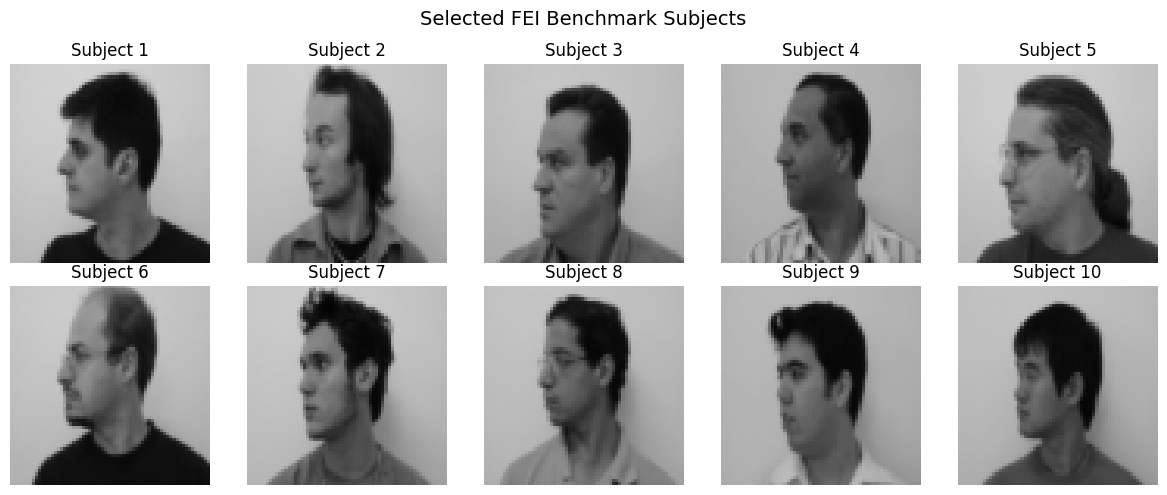

In [8]:
sample_rows = benchmark_metadata.groupby("subject_id", sort=True).head(1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for axis, row_index in zip(axes.ravel(), sample_rows.index):
    axis.imshow(X_images[row_index], cmap="gray", vmin=0.0, vmax=1.0)
    axis.set_title(f"Subject {benchmark_metadata.loc[row_index, 'subject_id']}")
    axis.axis("off")

fig.suptitle("Selected FEI Benchmark Subjects", fontsize=14)
plt.tight_layout()
plt.show()

# 2. Controlled Train, Validation and Test Split

The same fixed, stratified indices are used for every feature-extraction method. The validation set is used for development, while the held-out test set remains locked.

In [9]:
all_indices = np.arange(len(X_images), dtype=np.int64)

development_indices, test_indices = train_test_split(
    all_indices,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

train_indices, validation_indices = train_test_split(
    development_indices,
    test_size=VALIDATION_SIZE_WITHIN_DEVELOPMENT,
    random_state=RANDOM_STATE,
    stratify=y[development_indices],
)

X_train, y_train = X_images[train_indices], y[train_indices]
X_validation, y_validation = X_images[validation_indices], y[validation_indices]
X_test, y_test = X_images[test_indices], y[test_indices]

expected_sizes = {"training": 84, "validation": 28, "test": 28}
actual_sizes = {
    "training": len(train_indices),
    "validation": len(validation_indices),
    "test": len(test_indices),
}

if actual_sizes != expected_sizes:
    raise ValueError(f"Unexpected split sizes: {actual_sizes}")

sets = [set(train_indices), set(validation_indices), set(test_indices)]
if sets[0] & sets[1] or sets[0] & sets[2] or sets[1] & sets[2]:
    raise ValueError("Split overlap detected.")

if set.union(*sets) != set(all_indices):
    raise ValueError("Splits do not cover every image exactly once.")

print("PASS: fixed split indices are disjoint and complete.")

PASS: fixed split indices are disjoint and complete.


In [10]:
def image_fingerprint(image: np.ndarray) -> bytes:
    return np.ascontiguousarray(image, dtype=np.float32).tobytes()

train_fingerprints = {image_fingerprint(image) for image in X_train}
validation_fingerprints = {image_fingerprint(image) for image in X_validation}
test_fingerprints = {image_fingerprint(image) for image in X_test}

if train_fingerprints & validation_fingerprints:
    raise ValueError("Duplicate content crosses training and validation.")

if train_fingerprints & test_fingerprints:
    raise ValueError("Duplicate content crosses training and test.")

if validation_fingerprints & test_fingerprints:
    raise ValueError("Duplicate content crosses validation and test.")

expected_labels = set(range(len(SELECTED_SUBJECTS)))
for split_name, labels in [
    ("training", y_train),
    ("validation", y_validation),
    ("test", y_test),
]:
    if set(np.unique(labels)) != expected_labels:
        raise ValueError(f"{split_name} does not contain every class.")

print("PASS: class coverage and duplicate-content checks passed.")

PASS: class coverage and duplicate-content checks passed.


In [11]:
benchmark_metadata["split"] = "unassigned"
benchmark_metadata.loc[train_indices, "split"] = "training"
benchmark_metadata.loc[validation_indices, "split"] = "validation"
benchmark_metadata.loc[test_indices, "split"] = "test"

if (benchmark_metadata["split"] == "unassigned").any():
    raise ValueError("At least one image was not assigned to a split.")

SPLIT_MANIFEST_FILE = RESULTS_DIR / "fei_controlled_split_manifest.csv"

benchmark_metadata[
    ["filename", "subject_id", "image_number", "label", "split"]
].to_csv(SPLIT_MANIFEST_FILE, index=False)

print("=" * 70)
print("Controlled data split")
print("=" * 70)
print(f"Training   : {X_train.shape}")
print(f"Validation : {X_validation.shape}")
print(f"Test       : {X_test.shape}")
print(f"Test locked: {LOCK_TEST_SET}")
print(f"Manifest   : {SPLIT_MANIFEST_FILE}")
print("=" * 70)

Controlled data split
Training   : (84, 64, 64)
Validation : (28, 64, 64)
Test       : (28, 64, 64)
Test locked: True
Manifest   : <PROJECT_ROOT>\results\fei_benchmark\benchmark_results\fei_controlled_split_manifest.csv


# 3. Shared Feature-Extraction and Classification Pipeline

Dimension-controlled methods must return exactly eight finite values per image. Scaling is fitted on training features only, and the same linear SVM is used throughout.

In [12]:
def validate_feature_vector(
    values: Any,
    *,
    image_index: int,
    expected_features: int | None,
    split_name: str,
) -> np.ndarray:
    vector = np.asarray(values, dtype=np.float64).reshape(-1)

    if vector.size == 0:
        raise ValueError(f"{split_name} image {image_index} returned no features.")

    if expected_features is not None and vector.shape != (expected_features,):
        raise ValueError(
            f"{split_name} image {image_index} returned {vector.shape}; "
            f"expected ({expected_features},)."
        )

    if not np.all(np.isfinite(vector)):
        raise ValueError(f"{split_name} image {image_index} returned non-finite values.")

    return vector

def build_feature_matrix(
    images: np.ndarray,
    feature_extractor: Callable[[np.ndarray], np.ndarray],
    *,
    split_name: str,
    expected_features: int | None = N_FEATURES,
) -> tuple[np.ndarray, float]:
    image_array = np.asarray(images)

    if image_array.ndim != 3 or len(image_array) == 0:
        raise ValueError(f"Invalid {split_name} image array: {image_array.shape}")

    started = time.perf_counter()
    rows = []
    inferred_count = expected_features

    for index, image in enumerate(image_array):
        vector = validate_feature_vector(
            feature_extractor(image),
            image_index=index,
            expected_features=inferred_count,
            split_name=split_name,
        )

        if inferred_count is None:
            inferred_count = vector.size

        if vector.shape != (inferred_count,):
            raise ValueError("Inconsistent feature dimension.")

        rows.append(vector)

    matrix = np.vstack(rows).astype(np.float64, copy=False)

    if not np.all(np.isfinite(matrix)):
        raise ValueError(f"{split_name} matrix contains non-finite values.")

    return matrix, float(time.perf_counter() - started)

def validate_training_feature_matrix(features: np.ndarray) -> None:
    constant_columns = np.where(np.isclose(np.std(features, axis=0), 0.0))[0]
    if len(constant_columns):
        raise ValueError(f"Constant training columns: {constant_columns.tolist()}")

In [13]:
def evaluate_feature_extractor(
    feature_extractor: Callable[[np.ndarray], np.ndarray],
    *,
    method_name: str,
    expected_features: int | None = N_FEATURES,
    comparison_group: str = "dimension_controlled",
    evaluate_test: bool = False,
) -> dict[str, Any]:
    if evaluate_test and LOCK_TEST_SET:
        raise PermissionError(
            "The test set is locked. Set LOCK_TEST_SET=False only after "
            "all development decisions are complete."
        )

    train_features, train_extract_time = build_feature_matrix(
        X_train,
        feature_extractor,
        split_name="training",
        expected_features=expected_features,
    )

    validation_features, validation_extract_time = build_feature_matrix(
        X_validation,
        feature_extractor,
        split_name="validation",
        expected_features=train_features.shape[1],
    )

    validate_training_feature_matrix(train_features)

    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_features)
    validation_scaled = scaler.transform(validation_features)

    classifier = SVC(
        kernel=SVM_KERNEL,
        C=SVM_C,
        random_state=RANDOM_STATE,
    )

    train_started = time.perf_counter()
    classifier.fit(train_scaled, y_train)
    classifier_training_time = time.perf_counter() - train_started

    prediction_started = time.perf_counter()
    validation_predictions = classifier.predict(validation_scaled)
    validation_prediction_time = time.perf_counter() - prediction_started

    validation_accuracy = float(
        accuracy_score(y_validation, validation_predictions)
    )

    result = {
        "method": method_name,
        "comparison_group": comparison_group,
        "dataset_name": DATASET_NAME,
        "data_source_type": DATA_SOURCE_TYPE,
        "feature_dimension": int(train_features.shape[1]),
        "expected_feature_dimension": expected_features,
        "image_size": IMAGE_SIZE,
        "random_state": RANDOM_STATE,
        "svm_kernel": SVM_KERNEL,
        "svm_c": SVM_C,
        "training_feature_shape": train_features.shape,
        "validation_feature_shape": validation_features.shape,
        "test_feature_shape": None,
        "validation_accuracy": validation_accuracy,
        "test_accuracy": None,
        "test_evaluated": False,
        "total_feature_extraction_time_seconds": float(
            train_extract_time + validation_extract_time
        ),
        "classifier_training_time_seconds": float(classifier_training_time),
        "validation_prediction_time_seconds": float(validation_prediction_time),
        "scaler": scaler,
        "classifier": classifier,
        "training_features": train_features,
        "validation_features": validation_features,
        "test_features": None,
        "validation_predictions": validation_predictions,
        "test_predictions": None,
    }

    if evaluate_test:
        test_features, test_extract_time = build_feature_matrix(
            X_test,
            feature_extractor,
            split_name="test",
            expected_features=train_features.shape[1],
        )

        test_scaled = scaler.transform(test_features)
        test_predictions = classifier.predict(test_scaled)

        result.update(
            {
                "test_feature_shape": test_features.shape,
                "test_accuracy": float(accuracy_score(y_test, test_predictions)),
                "test_evaluated": True,
                "total_feature_extraction_time_seconds": float(
                    train_extract_time + validation_extract_time + test_extract_time
                ),
                "test_features": test_features,
                "test_predictions": test_predictions,
            }
        )

    print("=" * 70)
    print(f"Method               : {method_name}")
    print(f"Comparison group     : {comparison_group}")
    print(f"Feature dimension    : {result['feature_dimension']}")
    print(f"Validation accuracy  : {validation_accuracy * 100:.2f}%")
    print(f"Test evaluated       : {result['test_evaluated']}")
    print("=" * 70)

    return result

def summarise_benchmark_result(result: dict[str, Any]) -> dict[str, Any]:
    return {
        "method": result["method"],
        "comparison_group": result["comparison_group"],
        "dataset_name": result["dataset_name"],
        "feature_dimension": result["feature_dimension"],
        "validation_accuracy": result["validation_accuracy"],
        "test_accuracy": result["test_accuracy"],
        "test_evaluated": result["test_evaluated"],
        "total_feature_extraction_time_seconds": result[
            "total_feature_extraction_time_seconds"
        ],
        "classifier_training_time_seconds": result[
            "classifier_training_time_seconds"
        ],
    }

# 4. Handcrafted Eight-Feature Baseline

This deterministic baseline returns eight named and interpretable features for each preprocessed image.

In [14]:
HANDCRAFTED_FEATURE_METADATA = [
    {"index": 0, "name": "global_mean", "description": "Mean full-image intensity."},
    {"index": 1, "name": "global_standard_deviation", "description": "Full-image intensity variability."},
    {"index": 2, "name": "central_region_mean", "description": "Mean central-region intensity."},
    {"index": 3, "name": "central_region_standard_deviation", "description": "Central-region intensity variability."},
    {"index": 4, "name": "horizontal_gradient_mean", "description": "Mean absolute horizontal difference."},
    {"index": 5, "name": "vertical_gradient_mean", "description": "Mean absolute vertical difference."},
    {"index": 6, "name": "left_right_symmetry_difference", "description": "Mean mirrored half-image difference."},
    {"index": 7, "name": "bright_pixel_proportion", "description": "Proportion above mean plus one standard deviation."},
]

HANDCRAFTED_FEATURE_NAMES = [
    item["name"] for item in HANDCRAFTED_FEATURE_METADATA
]

if len(HANDCRAFTED_FEATURE_NAMES) != N_FEATURES:
    raise ValueError("Handcrafted metadata does not contain eight features.")

pd.DataFrame(HANDCRAFTED_FEATURE_METADATA)

,index,name,description
0,0,global_mean,Mean full-image intensity.
1,1,global_standard_deviation,Full-image intensity variability.
2,2,central_region_mean,Mean central-region intensity.
3,3,central_region_standard_deviation,Central-region intensity variability.
4,4,horizontal_gradient_mean,Mean absolute horizontal difference.
5,5,vertical_gradient_mean,Mean absolute vertical difference.
6,6,left_right_symmetry_difference,Mean mirrored half-image difference.
7,7,bright_pixel_proportion,Proportion above mean plus one standard deviat...


In [15]:
def extract_central_region(image: np.ndarray) -> np.ndarray:
    height, width = image.shape

    region = image[
        int(0.20 * height):int(0.85 * height),
        int(0.20 * width):int(0.80 * width),
    ]

    if region.size == 0:
        raise ValueError("Central-region crop is empty.")

    return region

def handcrafted_feature_extractor(image: np.ndarray) -> np.ndarray:
    image = np.asarray(image, dtype=np.float64)

    if image.ndim != 2 or not np.all(np.isfinite(image)):
        raise ValueError("Handcrafted extractor requires a finite 2-D image.")

    global_mean = float(np.mean(image))
    global_std = float(np.std(image))

    centre = extract_central_region(image)

    horizontal = float(np.mean(np.abs(np.diff(image, axis=1))))
    vertical = float(np.mean(np.abs(np.diff(image, axis=0))))

    half_width = image.shape[1] // 2
    left = image[:, :half_width]
    right = np.fliplr(image[:, image.shape[1] - half_width:])

    features = np.array(
        [
            global_mean,
            global_std,
            float(np.mean(centre)),
            float(np.std(centre)),
            horizontal,
            vertical,
            float(np.mean(np.abs(left - right))),
            float(np.mean(image > global_mean + global_std)),
        ],
        dtype=np.float64,
    )

    return validate_feature_vector(
        features,
        image_index=0,
        expected_features=N_FEATURES,
        split_name="handcrafted extractor",
    )

In [16]:
sample = handcrafted_feature_extractor(X_train[0])

for name, value in zip(HANDCRAFTED_FEATURE_NAMES, sample):
    print(f"{name:<40}: {value:.6f}")

print(f"Output shape: {sample.shape}")
print("PASS: handcrafted extractor contract verified.")

global_mean                             : 0.164100
global_standard_deviation               : 0.078944
central_region_mean                     : 0.138279
central_region_standard_deviation       : 0.066642
horizontal_gradient_mean                : 0.008510
vertical_gradient_mean                  : 0.006434
left_right_symmetry_difference          : 0.021445
bright_pixel_proportion                 : 0.130371
Output shape: (8,)
PASS: handcrafted extractor contract verified.


In [17]:
handcrafted_result = evaluate_feature_extractor(
    feature_extractor=handcrafted_feature_extractor,
    method_name="Handcrafted-8",
    expected_features=N_FEATURES,
    comparison_group="dimension_controlled",
    evaluate_test=False,
)

HANDCRAFTED_METADATA_FILE = RESULTS_DIR / "handcrafted8_feature_metadata.json"
HANDCRAFTED_SUMMARY_FILE = RESULTS_DIR / "handcrafted8_validation_summary.json"

with open(HANDCRAFTED_METADATA_FILE, "w", encoding="utf-8") as file:
    json.dump(HANDCRAFTED_FEATURE_METADATA, file, indent=4)

with open(HANDCRAFTED_SUMMARY_FILE, "w", encoding="utf-8") as file:
    json.dump(summarise_benchmark_result(handcrafted_result), file, indent=4)

print(HANDCRAFTED_SUMMARY_FILE)

Method               : Handcrafted-8
Comparison group     : dimension_controlled
Feature dimension    : 8
Validation accuracy  : 71.43%
Test evaluated       : False
<PROJECT_ROOT>\results\fei_benchmark\benchmark_results\handcrafted8_validation_summary.json


# 5. Original Genetic Programming — Unrestricted Reference

The Original GP implementation is retained as an unrestricted reference method.

It may return substantially more than eight features and currently uses its own internal GP evaluation pipeline. It is therefore not yet part of the fair dimension-controlled comparison against Handcrafted-8 and EOH-8.

The implementation receives:

- the benchmark training partition as training data;
- the benchmark validation partition through its internally named `x_test` and `y_test` arguments;
- no access to the held-out benchmark test partition.

The existing saved checkpoint is loaded by default. A new GP run occurs only when explicitly enabled.

In [18]:
# -------------------------------------------------------
# Load one isolated gp_fr package
# -------------------------------------------------------

def load_gp_fr_package(
    package_parent: Path,
):
    """
    Load the gp_fr package under one specified parent folder.

    Existing gp_fr modules are removed first because the
    Original and Modified implementations use the same
    Python package name.
    """
    package_parent = package_parent.resolve()

    if not package_parent.exists():
        raise FileNotFoundError(
            "GP package parent not found:\n"
            f"{package_parent}"
        )

    modules_to_remove = [
        module_name
        for module_name in list(sys.modules)
        if (
            module_name == "gp_fr"
            or module_name.startswith("gp_fr.")
        )
    ]

    for module_name in modules_to_remove:
        del sys.modules[module_name]

    package_parent_string = str(
        package_parent
    )

    sys.path = [
        path_entry
        for path_entry in sys.path
        if path_entry != package_parent_string
    ]

    sys.path.insert(
        0,
        package_parent_string,
    )

    importlib.invalidate_caches()

    imported_package = importlib.import_module(
        "gp_fr"
    )

    return imported_package

In [20]:
# -------------------------------------------------------
# Original GP paths and import
# -------------------------------------------------------

ORIGINAL_GP_PARENT = (
    PROJECT_ROOT
    / "src"
    / "legacy"
    / "gp_original"
)

ORIGINAL_GP_PACKAGE_DIR = (
    ORIGINAL_GP_PARENT
    / "gp_fr"
)

ORIGINAL_GP_CHECKPOINT_FILE = (
    PROJECT_ROOT
    / "results"
    / "fei_benchmark"
    / "checkpoints"
    / "original_gp_result.pkl"
)

ORIGINAL_GP_SUMMARY_FILE = (
    RESULTS_DIR
    / "original_gp_unrestricted_summary.json"
)

# -------------------------------------------------------
# Validate required files and folders
# -------------------------------------------------------

if not ORIGINAL_GP_PACKAGE_DIR.exists():
    raise FileNotFoundError(
        "Original GP package not found:\n"
        f"{ORIGINAL_GP_PACKAGE_DIR}"
    )

if not ORIGINAL_GP_CHECKPOINT_FILE.exists():
    raise FileNotFoundError(
        "Original GP checkpoint not found:\n"
        f"{ORIGINAL_GP_CHECKPOINT_FILE}"
    )

# -------------------------------------------------------
# Import Original GP
# -------------------------------------------------------

original_gp_fr = load_gp_fr_package(
    ORIGINAL_GP_PARENT
)

original_gp_module_path = Path(
    original_gp_fr.__file__
).resolve()

if ORIGINAL_GP_PARENT.resolve() not in (
    original_gp_module_path.parents
):
    raise ImportError(
        "Wrong Original GP package loaded from:\n"
        f"{original_gp_module_path}"
    )

if not hasattr(
    original_gp_fr,
    "run_gp_fr",
):
    raise AttributeError(
        "Original GP package does not expose run_gp_fr."
    )

# -------------------------------------------------------
# Display verified configuration
# -------------------------------------------------------

print("=" * 70)
print("Original GP configuration")
print("=" * 70)

print(
    f"Package directory : "
    f"{ORIGINAL_GP_PACKAGE_DIR}"
)

print(
    f"Imported module   : "
    f"{original_gp_module_path}"
)

print(
    f"Checkpoint        : "
    f"{ORIGINAL_GP_CHECKPOINT_FILE}"
)

print("\nrun_gp_fr signature:")

print(
    inspect.signature(
        original_gp_fr.run_gp_fr
    )
)

print(
    "\nPopulation :",
    original_gp_fr.gp_fr_main.POPULATION,
)

print(
    "Generations:",
    original_gp_fr.gp_fr_main.GENERATION,
)

print("=" * 70)
print(
    "PASS: Original GP package and checkpoint verified."
)

Original GP configuration
Package directory : <PROJECT_ROOT>\src\legacy\gp_original\gp_fr
Imported module   : <PROJECT_ROOT>\src\legacy\gp_original\gp_fr\__init__.py
Checkpoint        : <PROJECT_ROOT>\results\fei_benchmark\checkpoints\original_gp_result.pkl

run_gp_fr signature:
(x_train, y_train, x_test, y_test, seed=0, verbose=True)

Population : 250
Generations: 10
PASS: Original GP package and checkpoint verified.


In [21]:
# -------------------------------------------------------
# Load or run Original GP
# -------------------------------------------------------

RUN_ORIGINAL_GP = False

if ORIGINAL_GP_CHECKPOINT_FILE.exists():

    print("=" * 70)
    print("Loading Original GP checkpoint")
    print("=" * 70)

    print(
        ORIGINAL_GP_CHECKPOINT_FILE
    )

    with open(
        ORIGINAL_GP_CHECKPOINT_FILE,
        "rb",
    ) as file:
        original_gp_raw_result = pickle.load(
            file
        )

    if not isinstance(
        original_gp_raw_result,
        dict,
    ):
        raise TypeError(
            "The Original GP checkpoint did not contain "
            "a dictionary. Received: "
            f"{type(original_gp_raw_result).__name__}"
        )

    print("\nOriginal GP checkpoint loaded.")

    print("\nAvailable result keys:")

    print(
        sorted(
            original_gp_raw_result.keys()
        )
    )

elif RUN_ORIGINAL_GP:

    print("Running Original GP...")

    run_started = time.perf_counter()

    original_gp_raw_result = (
        original_gp_fr.run_gp_fr(
            x_train=X_train,
            y_train=y_train,
            x_test=X_validation,
            y_test=y_validation,
            seed=RANDOM_STATE,
            verbose=True,
        )
    )

    if not isinstance(
        original_gp_raw_result,
        dict,
    ):
        raise TypeError(
            "Original GP run_gp_fr() did not return "
            "a dictionary."
        )

    original_gp_raw_result[
        "benchmark_wall_time_seconds"
    ] = float(
        time.perf_counter()
        - run_started
    )

    with open(
        ORIGINAL_GP_CHECKPOINT_FILE,
        "wb",
    ) as file:
        pickle.dump(
            original_gp_raw_result,
            file,
        )

    print(
        "Original GP run completed and "
        "checkpoint saved."
    )

else:

    raise FileNotFoundError(
        "No Original GP checkpoint exists and "
        "RUN_ORIGINAL_GP=False.\n"
        f"Expected checkpoint:\n"
        f"{ORIGINAL_GP_CHECKPOINT_FILE}"
    )

Loading Original GP checkpoint
<PROJECT_ROOT>\results\fei_benchmark\checkpoints\original_gp_result.pkl

Original GP checkpoint loaded.

Available result keys:
['classifier', 'feature_dim', 'program', 'test_acc', 'test_features', 'train_features', 'train_fitness', 'train_time']


In [22]:
# -------------------------------------------------------
# Validate and standardise Original GP result
# -------------------------------------------------------

required_gp_keys = {
    "test_acc",
    "train_fitness",
    "feature_dim",
    "train_time",
    "classifier",
    "program",
}

missing_original_gp_keys = (
    required_gp_keys
    - set(original_gp_raw_result)
)

if missing_original_gp_keys:
    raise KeyError(
        "Original GP result is missing required keys: "
        f"{sorted(missing_original_gp_keys)}"
    )

raw_original_accuracy = float(
    original_gp_raw_result[
        "test_acc"
    ]
)

# Older checkpoints store percentage values such as
# 100.0 rather than proportions such as 1.0.
original_validation_accuracy = (
    raw_original_accuracy / 100.0
    if raw_original_accuracy > 1.0
    else raw_original_accuracy
)

if not (
    0.0
    <= original_validation_accuracy
    <= 1.0
):
    raise ValueError(
        "Original GP validation accuracy is outside "
        "[0, 1] after normalisation."
    )

original_feature_dimension = int(
    original_gp_raw_result[
        "feature_dim"
    ]
)

if original_feature_dimension < 1:
    raise ValueError(
        "Original GP feature dimension must be positive."
    )

original_gp_result = {
    "method": "Original GP — Unrestricted",
    "comparison_group": "unrestricted_reference",
    "evaluation_pipeline": (
        "original_gp_internal_pipeline"
    ),
    "dataset_name": DATASET_NAME,
    "data_source_type": DATA_SOURCE_TYPE,

    "feature_dimension": (
        original_feature_dimension
    ),

    "expected_feature_dimension": None,

    # Standard benchmark representation.
    "validation_accuracy": (
        original_validation_accuracy
    ),

    # Exact checkpoint value retained for traceability.
    "raw_checkpoint_validation_accuracy": (
        raw_original_accuracy
    ),

    "raw_checkpoint_accuracy_scale": (
        "percentage"
        if raw_original_accuracy > 1.0
        else "proportion"
    ),

    "test_accuracy": None,
    "test_evaluated": False,

    # Preserve the raw fitness value because its exact
    # scale and interpretation belong to the GP pipeline.
    "training_fitness_raw": float(
        original_gp_raw_result[
            "train_fitness"
        ]
    ),

    "training_time_seconds": float(
        original_gp_raw_result[
            "train_time"
        ]
    ),

    "population": int(
        original_gp_fr
        .gp_fr_main
        .POPULATION
    ),

    "generations": int(
        original_gp_fr
        .gp_fr_main
        .GENERATION
    ),

    "random_state": RANDOM_STATE,

    "program": original_gp_raw_result[
        "program"
    ],

    "classifier": original_gp_raw_result[
        "classifier"
    ],

    "raw_result": original_gp_raw_result,
}

original_gp_summary = {
    key: value
    for key, value in original_gp_result.items()
    if key not in {
        "program",
        "classifier",
        "raw_result",
    }
}

original_gp_summary[
    "checkpoint_file"
] = str(
    ORIGINAL_GP_CHECKPOINT_FILE
)

with open(
    ORIGINAL_GP_SUMMARY_FILE,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        original_gp_summary,
        file,
        indent=4,
    )

print("=" * 70)
print("Original GP — Unrestricted Reference")
print("=" * 70)

print(
    f"Features                 : "
    f"{original_gp_result['feature_dimension']}"
)

print(
    f"Validation accuracy      : "
    f"{original_gp_result['validation_accuracy'] * 100:.2f}%"
)

print(
    f"Raw checkpoint accuracy  : "
    f"{original_gp_result['raw_checkpoint_validation_accuracy']}"
)

print(
    f"Raw accuracy scale       : "
    f"{original_gp_result['raw_checkpoint_accuracy_scale']}"
)

print(
    f"Raw training fitness     : "
    f"{original_gp_result['training_fitness_raw']}"
)

print(
    f"Training time            : "
    f"{original_gp_result['training_time_seconds']:.4f} seconds"
)

print(
    f"Test evaluated           : "
    f"{original_gp_result['test_evaluated']}"
)

print("=" * 70)

Original GP — Unrestricted Reference
Features                 : 768
Validation accuracy      : 100.00%
Raw checkpoint accuracy  : 100.0
Raw accuracy scale       : percentage
Raw training fitness     : 100.0
Training time            : 2537.2570 seconds
Test evaluated           : False


### Original GP test-set status

The Original GP implementation received only the benchmark training and validation partitions.

Its internally named `x_test` and `y_test` arguments contain the benchmark validation split.

The held-out benchmark test arrays were not supplied to the Original GP implementation and remain locked.

# 6. Modified Genetic Programming — Unrestricted Reference

The Modified GP implementation extends the Original GP search space with additional feature-extraction primitives.

Like Original GP, it remains unrestricted and may return substantially more than eight features. It currently uses its own internal GP evaluation pipeline and is therefore retained as a reference method rather than part of the dimension-controlled comparison.

The implementation receives:

- the benchmark training partition as training data;
- the benchmark validation partition through its internally named `x_test` and `y_test` arguments;
- no access to the held-out benchmark test partition.

The existing saved checkpoint is loaded by default. A new Modified GP run occurs only when explicitly enabled.

In [24]:
# -------------------------------------------------------
# Modified GP paths and import
# -------------------------------------------------------

MODIFIED_GP_PARENT = (
    PROJECT_ROOT
    / "src"
    / "legacy"
    / "gp_modified"
)

MODIFIED_GP_PACKAGE_DIR = (
    MODIFIED_GP_PARENT
    / "gp_fr"
)

MODIFIED_GP_CHECKPOINT_FILE = (
    PROJECT_ROOT
    / "results"
    / "fei_benchmark"
    / "checkpoints"
    / "modified_gp_result.pkl"
)

MODIFIED_GP_SUMMARY_FILE = (
    RESULTS_DIR
    / "modified_gp_unrestricted_summary.json"
)

# -------------------------------------------------------
# Validate required files and folders
# -------------------------------------------------------

if not MODIFIED_GP_PACKAGE_DIR.exists():
    raise FileNotFoundError(
        "Modified GP package not found:\n"
        f"{MODIFIED_GP_PACKAGE_DIR}"
    )

if not MODIFIED_GP_CHECKPOINT_FILE.exists():
    raise FileNotFoundError(
        "Modified GP checkpoint not found:\n"
        f"{MODIFIED_GP_CHECKPOINT_FILE}"
    )

# -------------------------------------------------------
# Import Modified GP
# -------------------------------------------------------

modified_gp_fr = load_gp_fr_package(
    MODIFIED_GP_PARENT
)

modified_gp_module_path = Path(
    modified_gp_fr.__file__
).resolve()

if MODIFIED_GP_PARENT.resolve() not in (
    modified_gp_module_path.parents
):
    raise ImportError(
        "Wrong Modified GP package loaded from:\n"
        f"{modified_gp_module_path}"
    )

if not hasattr(
    modified_gp_fr,
    "run_gp_fr",
):
    raise AttributeError(
        "Modified GP package does not expose run_gp_fr."
    )

# -------------------------------------------------------
# Display verified configuration
# -------------------------------------------------------

print("=" * 70)
print("Modified GP configuration")
print("=" * 70)

print(
    f"Package directory : "
    f"{MODIFIED_GP_PACKAGE_DIR}"
)

print(
    f"Imported module   : "
    f"{modified_gp_module_path}"
)

print(
    f"Checkpoint        : "
    f"{MODIFIED_GP_CHECKPOINT_FILE}"
)

print("\nrun_gp_fr signature:")

print(
    inspect.signature(
        modified_gp_fr.run_gp_fr
    )
)

print(
    "\nPopulation :",
    modified_gp_fr.gp_fr_main.POPULATION,
)

print(
    "Generations:",
    modified_gp_fr.gp_fr_main.GENERATION,
)

print("=" * 70)
print(
    "PASS: Modified GP package and checkpoint verified."
)

Modified GP configuration
Package directory : <PROJECT_ROOT>\src\legacy\gp_modified\gp_fr
Imported module   : <PROJECT_ROOT>\src\legacy\gp_modified\gp_fr\__init__.py
Checkpoint        : <PROJECT_ROOT>\results\fei_benchmark\checkpoints\modified_gp_result.pkl

run_gp_fr signature:
(x_train, y_train, x_test, y_test, seed=0, verbose=True)

Population : 250
Generations: 10
PASS: Modified GP package and checkpoint verified.


In [25]:
# -------------------------------------------------------
# Load or run Modified GP
# -------------------------------------------------------

RUN_MODIFIED_GP = False

if MODIFIED_GP_CHECKPOINT_FILE.exists():

    print("=" * 70)
    print("Loading Modified GP checkpoint")
    print("=" * 70)

    print(
        MODIFIED_GP_CHECKPOINT_FILE
    )

    with open(
        MODIFIED_GP_CHECKPOINT_FILE,
        "rb",
    ) as file:
        modified_gp_raw_result = pickle.load(
            file
        )

    if not isinstance(
        modified_gp_raw_result,
        dict,
    ):
        raise TypeError(
            "The Modified GP checkpoint did not contain "
            "a dictionary. Received: "
            f"{type(modified_gp_raw_result).__name__}"
        )

    print("\nModified GP checkpoint loaded.")

    print("\nAvailable result keys:")

    print(
        sorted(
            modified_gp_raw_result.keys()
        )
    )

elif RUN_MODIFIED_GP:

    print("Running Modified GP...")

    run_started = time.perf_counter()

    modified_gp_raw_result = (
        modified_gp_fr.run_gp_fr(
            x_train=X_train,
            y_train=y_train,
            x_test=X_validation,
            y_test=y_validation,
            seed=RANDOM_STATE,
            verbose=True,
        )
    )

    if not isinstance(
        modified_gp_raw_result,
        dict,
    ):
        raise TypeError(
            "Modified GP run_gp_fr() did not return "
            "a dictionary."
        )

    modified_gp_raw_result[
        "benchmark_wall_time_seconds"
    ] = float(
        time.perf_counter()
        - run_started
    )

    with open(
        MODIFIED_GP_CHECKPOINT_FILE,
        "wb",
    ) as file:
        pickle.dump(
            modified_gp_raw_result,
            file,
        )

    print(
        "Modified GP run completed and "
        "checkpoint saved."
    )

else:

    raise FileNotFoundError(
        "No Modified GP checkpoint exists and "
        "RUN_MODIFIED_GP=False.\n"
        f"Expected checkpoint:\n"
        f"{MODIFIED_GP_CHECKPOINT_FILE}"
    )

Loading Modified GP checkpoint
<PROJECT_ROOT>\results\fei_benchmark\checkpoints\modified_gp_result.pkl

Modified GP checkpoint loaded.

Available result keys:
['classifier', 'feature_dim', 'program', 'test_acc', 'test_features', 'train_features', 'train_fitness', 'train_time']


In [27]:
# -------------------------------------------------------
# Validate and standardise Modified GP result
# -------------------------------------------------------

required_modified_gp_keys = {
    "test_acc",
    "train_fitness",
    "feature_dim",
    "train_time",
    "classifier",
    "program",
}

missing_modified_gp_keys = (
    required_modified_gp_keys
    - set(modified_gp_raw_result)
)

if missing_modified_gp_keys:
    raise KeyError(
        "Modified GP result is missing required keys: "
        f"{sorted(missing_modified_gp_keys)}"
    )

raw_modified_accuracy = float(
    modified_gp_raw_result[
        "test_acc"
    ]
)

# Older checkpoints store percentage values such as
# 100.0 rather than proportions such as 1.0.
modified_validation_accuracy = (
    raw_modified_accuracy / 100.0
    if raw_modified_accuracy > 1.0
    else raw_modified_accuracy
)

if not (
    0.0
    <= modified_validation_accuracy
    <= 1.0
):
    raise ValueError(
        "Modified GP validation accuracy is outside "
        "[0, 1] after normalisation."
    )

modified_feature_dimension = int(
    modified_gp_raw_result[
        "feature_dim"
    ]
)

if modified_feature_dimension < 1:
    raise ValueError(
        "Modified GP feature dimension must be positive."
    )

modified_gp_result = {
    "method": "Modified GP — Unrestricted",
    "comparison_group": "unrestricted_reference",
    "evaluation_pipeline": (
        "modified_gp_internal_pipeline"
    ),
    "dataset_name": DATASET_NAME,
    "data_source_type": DATA_SOURCE_TYPE,

    "feature_dimension": (
        modified_feature_dimension
    ),

    "expected_feature_dimension": None,

    # Standard benchmark representation.
    "validation_accuracy": (
        modified_validation_accuracy
    ),

    # Exact checkpoint value retained for traceability.
    "raw_checkpoint_validation_accuracy": (
        raw_modified_accuracy
    ),

    "raw_checkpoint_accuracy_scale": (
        "percentage"
        if raw_modified_accuracy > 1.0
        else "proportion"
    ),

    "test_accuracy": None,
    "test_evaluated": False,

    # Preserve the raw GP fitness without changing scale.
    "training_fitness_raw": float(
        modified_gp_raw_result[
            "train_fitness"
        ]
    ),

    "training_time_seconds": float(
        modified_gp_raw_result[
            "train_time"
        ]
    ),

    "population": int(
        modified_gp_fr
        .gp_fr_main
        .POPULATION
    ),

    "generations": int(
        modified_gp_fr
        .gp_fr_main
        .GENERATION
    ),

    "random_state": RANDOM_STATE,

    "program": modified_gp_raw_result[
        "program"
    ],

    "classifier": modified_gp_raw_result[
        "classifier"
    ],

    "raw_result": modified_gp_raw_result,
}

modified_gp_summary = {
    key: value
    for key, value in modified_gp_result.items()
    if key not in {
        "program",
        "classifier",
        "raw_result",
    }
}

modified_gp_summary[
    "checkpoint_file"
] = str(
    MODIFIED_GP_CHECKPOINT_FILE
)

with open(
    MODIFIED_GP_SUMMARY_FILE,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        modified_gp_summary,
        file,
        indent=4,
    )

print("=" * 70)
print("Modified GP — Unrestricted Reference")
print("=" * 70)

print(
    f"Features                 : "
    f"{modified_gp_result['feature_dimension']}"
)

print(
    f"Validation accuracy      : "
    f"{modified_gp_result['validation_accuracy'] * 100:.2f}%"
)

print(
    f"Raw checkpoint accuracy  : "
    f"{modified_gp_result['raw_checkpoint_validation_accuracy']}"
)

print(
    f"Raw accuracy scale       : "
    f"{modified_gp_result['raw_checkpoint_accuracy_scale']}"
)

print(
    f"Raw training fitness     : "
    f"{modified_gp_result['training_fitness_raw']}"
)

print(
    f"Training time            : "
    f"{modified_gp_result['training_time_seconds']:.4f} seconds"
)

print(
    f"Test evaluated           : "
    f"{modified_gp_result['test_evaluated']}"
)

print("=" * 70)

Modified GP — Unrestricted Reference
Features                 : 164
Validation accuracy      : 100.00%
Raw checkpoint accuracy  : 100.0
Raw accuracy scale       : percentage
Raw training fitness     : 100.0
Training time            : 1389.3691 seconds
Test evaluated           : False


In [28]:
# -------------------------------------------------------
# Compare unrestricted GP reference results
# -------------------------------------------------------

unrestricted_gp_comparison = pd.DataFrame(
    [
        {
            "method": original_gp_result[
                "method"
            ],
            "feature_dimension": original_gp_result[
                "feature_dimension"
            ],
            "validation_accuracy": original_gp_result[
                "validation_accuracy"
            ],
            "validation_accuracy_percent": (
                100.0
                * original_gp_result[
                    "validation_accuracy"
                ]
            ),
            "raw_checkpoint_accuracy": original_gp_result[
                "raw_checkpoint_validation_accuracy"
            ],
            "training_fitness_raw": original_gp_result[
                "training_fitness_raw"
            ],
            "training_time_seconds": original_gp_result[
                "training_time_seconds"
            ],
        },
        {
            "method": modified_gp_result[
                "method"
            ],
            "feature_dimension": modified_gp_result[
                "feature_dimension"
            ],
            "validation_accuracy": modified_gp_result[
                "validation_accuracy"
            ],
            "validation_accuracy_percent": (
                100.0
                * modified_gp_result[
                    "validation_accuracy"
                ]
            ),
            "raw_checkpoint_accuracy": modified_gp_result[
                "raw_checkpoint_validation_accuracy"
            ],
            "training_fitness_raw": modified_gp_result[
                "training_fitness_raw"
            ],
            "training_time_seconds": modified_gp_result[
                "training_time_seconds"
            ],
        },
    ]
)

unrestricted_gp_comparison

,method,feature_dimension,validation_accuracy,validation_accuracy_percent,raw_checkpoint_accuracy,training_fitness_raw,training_time_seconds
0,Original GP — Unrestricted,768,1.0,100.0,100.0,100.0,2537.257002
1,Modified GP — Unrestricted,164,1.0,100.0,100.0,100.0,1389.369140


# 7. Restricted Original GP (8 Features)

## Purpose

This section implements the first restricted version of the original GP-FR
algorithm.

Unlike the unrestricted baseline, which is free to evolve feature vectors of
arbitrary dimensionality, this implementation constrains every valid GP
individual to produce **exactly eight explainable features**.

The objective is to create a fair, dimension-controlled comparison with the
other compact feature extraction methods developed in this project.

## Design

The restricted implementation introduces:

- A fixed eight-feature representation.
- Scalar, interpretable feature primitives.
- A strict FC8 root primitive producing an 8-dimensional feature vector.
- Validation that every evolved individual satisfies the eight-feature constraint.

The evolutionary process, crossover, mutation, and fitness evaluation remain
as close as possible to the original GP-FR implementation while enforcing the
fixed feature budget.

## Research Question

Can Genetic Programming evolve an explainable eight-feature representation that
matches or exceeds the performance of handcrafted and LLM-generated features
under identical evaluation conditions?

In [30]:
# -------------------------------------------------------
# Restricted Original GP-8 paths and package loading
# -------------------------------------------------------

RESTRICTED_ORIGINAL_GP_PARENT = (
    PROJECT_ROOT
    / "src"
    / "legacy"
    / "gp_restricted_original"
)

RESTRICTED_ORIGINAL_GP_PACKAGE_DIR = (
    RESTRICTED_ORIGINAL_GP_PARENT
    / "gp_fr"
)

RESTRICTED_ORIGINAL_GP_CHECKPOINT_FILE = (
    CHECKPOINTS_DIR
    / "restricted_original_gp8_result.pkl"
)

RESTRICTED_ORIGINAL_GP_SUMMARY_FILE = (
    RESULTS_DIR
    / "restricted_original_gp8_validation_summary.json"
)

if not RESTRICTED_ORIGINAL_GP_PACKAGE_DIR.exists():
    raise FileNotFoundError(
        "Restricted Original GP package was not found:\n"
        f"{RESTRICTED_ORIGINAL_GP_PACKAGE_DIR}"
    )

restricted_original_gp_fr = load_gp_fr_package(
    RESTRICTED_ORIGINAL_GP_PARENT
)

restricted_original_gp_module_path = Path(
    restricted_original_gp_fr.__file__
).resolve()

if RESTRICTED_ORIGINAL_GP_PARENT.resolve() not in (
    restricted_original_gp_module_path.parents
):
    raise ImportError(
        "The wrong gp_fr package was imported.\n"
        f"Imported from:\n{restricted_original_gp_module_path}"
    )

restricted_original_gp_main = (
    restricted_original_gp_fr.gp_fr_main
)

if not hasattr(
    restricted_original_gp_main,
    "run_gp_fr",
):
    raise AttributeError(
        "Restricted Original GP does not expose run_gp_fr()."
    )

if not hasattr(
    restricted_original_gp_main,
    "diagnose_random_feature_dimensions",
):
    raise AttributeError(
        "Restricted Original GP does not expose the "
        "dimension diagnostic."
    )

print("=" * 70)
print("Restricted Original GP-8 package configuration")
print("=" * 70)
print(
    f"Package directory : "
    f"{RESTRICTED_ORIGINAL_GP_PACKAGE_DIR}"
)
print(
    f"Imported module   : "
    f"{restricted_original_gp_module_path}"
)
print(
    f"Target dimension  : "
    f"{restricted_original_gp_main.TARGET_FEATURE_DIMENSION}"
)
print(
    f"Population        : "
    f"{restricted_original_gp_main.POPULATION}"
)
print(
    f"Generations       : "
    f"{restricted_original_gp_main.GENERATION}"
)
print(
    f"Checkpoint        : "
    f"{RESTRICTED_ORIGINAL_GP_CHECKPOINT_FILE}"
)
print("=" * 70)

if (
    restricted_original_gp_main.TARGET_FEATURE_DIMENSION
    != N_FEATURES
):
    raise ValueError(
        "Restricted GP target dimension does not match "
        f"the benchmark target of {N_FEATURES}."
    )

print(
    "PASS: Restricted Original GP-8 package loaded "
    "from the expected folder."
)

Restricted Original GP-8 package configuration
Package directory : <PROJECT_ROOT>\src\legacy\gp_restricted_original\gp_fr
Imported module   : <PROJECT_ROOT>\src\legacy\gp_restricted_original\gp_fr\__init__.py
Target dimension  : 8
Population        : 250
Generations       : 10
Checkpoint        : <PROJECT_ROOT>\results\fei_benchmark\checkpoints\restricted_original_gp8_result.pkl
PASS: Restricted Original GP-8 package loaded from the expected folder.


In [31]:
# -------------------------------------------------------
# Restricted Original GP-8 dimension diagnostic
# -------------------------------------------------------

restricted_original_gp8_dimension_diagnostic = (
    restricted_original_gp_main
    .diagnose_random_feature_dimensions(
        x_train=X_train,
        sample_size=50,
        seed=RANDOM_STATE,
    )
)

diagnostic = (
    restricted_original_gp8_dimension_diagnostic
)

if diagnostic["successful_programs"] == 0:
    raise RuntimeError(
        "The restricted grammar did not generate any "
        "successful programs."
    )

if diagnostic["minimum_dimension"] != N_FEATURES:
    raise RuntimeError(
        "At least one successful program returned fewer "
        "than eight features."
    )

if diagnostic["maximum_dimension"] != N_FEATURES:
    raise RuntimeError(
        "At least one successful program returned more "
        "than eight features."
    )

if (
    diagnostic["target_dimension_program_count"]
    != diagnostic["successful_programs"]
):
    raise RuntimeError(
        "Not every successful restricted program returned "
        "exactly eight features."
    )

print()
print(
    "PASS: every successful diagnostic program "
    "returned exactly eight features."
)

Restricted Original GP-8 dimension diagnostic
Target feature dimension : 8
Random programs requested: 50
Successful programs      : 50
Failed programs          : 0
Minimum dimension        : 8
Maximum dimension        : 8
Exactly 8 features     : 50

Observed feature dimensions:
     8 features :   50 programs

Example eight-feature program:
FC8(MinVal(Image), GradY(Image), Mean(Image), GradY_R(RegionS(Med(Image), 17, 13, 13)), Energy(Image), Median(Image), LapVar_R(MinFilter_R(MaxFilter_R(SobelY_R(LoG2_R(LoG2_R(Gau_R(SobelY_R(Sobel_R(Lap_R(Sobel_R(Lap_R(GauD_R(MaxFilter_R(MinFilter_R(LoG2_R(LoG1_R(MeanFilter_R(RegionR(Image, 9, 50, 38, 24)))))), 3, 2, 2)))))), 3))))))), MaxVal_R(SobelX_R(LoG2_R(RegionR(Gau(Image, 2), 10, 0, 32, 32)))))

PASS: every successful diagnostic program returned exactly eight features.


In [32]:
# -------------------------------------------------------
# Restricted Original GP-8 smoke test
# -------------------------------------------------------

RUN_RESTRICTED_ORIGINAL_GP8_SMOKE_TEST = True

if RUN_RESTRICTED_ORIGINAL_GP8_SMOKE_TEST:

    restricted_original_gp8_smoke_result = (
        restricted_original_gp_main.run_gp_fr(
            x_train=X_train,
            y_train=y_train,
            x_test=X_validation,
            y_test=y_validation,
            seed=RANDOM_STATE,
            verbose=True,
            population_size=20,
            generations=1,
        )
    )

    if not isinstance(
        restricted_original_gp8_smoke_result,
        dict,
    ):
        raise TypeError(
            "Restricted GP-8 smoke test did not return "
            "a dictionary."
        )

    smoke_dimension = int(
        restricted_original_gp8_smoke_result[
            "feature_dim"
        ]
    )

    if smoke_dimension != N_FEATURES:
        raise RuntimeError(
            "Restricted GP-8 smoke test returned "
            f"{smoke_dimension} features rather than "
            f"{N_FEATURES}."
        )

    smoke_train_features = np.asarray(
        restricted_original_gp8_smoke_result[
            "train_features"
        ]
    )

    smoke_validation_features = np.asarray(
        restricted_original_gp8_smoke_result[
            "test_features"
        ]
    )

    if smoke_train_features.shape != (
        len(X_train),
        N_FEATURES,
    ):
        raise RuntimeError(
            "Unexpected smoke-test training-feature shape: "
            f"{smoke_train_features.shape}"
        )

    if smoke_validation_features.shape != (
        len(X_validation),
        N_FEATURES,
    ):
        raise RuntimeError(
            "Unexpected smoke-test validation-feature shape: "
            f"{smoke_validation_features.shape}"
        )

    print("=" * 70)
    print("Restricted Original GP-8 smoke-test summary")
    print("=" * 70)
    print(
        f"Feature dimension   : "
        f"{smoke_dimension}"
    )
    print(
        f"Training features   : "
        f"{smoke_train_features.shape}"
    )
    print(
        f"Validation features : "
        f"{smoke_validation_features.shape}"
    )
    print(
        f"CV fitness          : "
        f"{restricted_original_gp8_smoke_result['train_fitness']}"
    )
    print(
        f"Validation accuracy : "
        f"{restricted_original_gp8_smoke_result['test_acc']}%"
    )
    print("=" * 70)
    print(
        "PASS: Restricted Original GP-8 smoke test completed."
    )

else:
    print("Restricted Original GP-8 smoke test skipped.")

gen	nevals	avg   	max  
0  	20    	40.588	69.04
1  	19    	67.131	73.9 

=== Restricted Original GP-8 Results (seed=42) ===
Training time: 18.4s
Best CV fitness: 73.90%
Validation accuracy: 85.71% (classifier: RF)
Feature dimension: 8
Program: FC8(Std(LoG2(MeanFilter(Image))), Median(LoG1(Med(Image))), Std(Gau(MeanFilter(Image), 2)), LapVar(LoG2(SobelY(Image))), Median(Sobel(Image)), Mean(Sobel(LoG1(Image))), Std_R(LoG1_R(MeanFilter_R(RegionR(GauD(Image, 1, 2, 1), 23, 58, 24, 49)))), Mean(SobelX(Sobel(Image))))
Restricted Original GP-8 smoke-test summary
Feature dimension   : 8
Training features   : (84, 8)
Validation features : (28, 8)
CV fitness          : 73.9
Validation accuracy : 85.71%
PASS: Restricted Original GP-8 smoke test completed.


In [34]:
# -------------------------------------------------------
# Full Restricted Original GP-8 run or checkpoint loading
# -------------------------------------------------------

RUN_RESTRICTED_ORIGINAL_GP8 = False

if RESTRICTED_ORIGINAL_GP_CHECKPOINT_FILE.exists():

    print(
        "Loading Restricted Original GP-8 checkpoint:"
    )
    print(
        RESTRICTED_ORIGINAL_GP_CHECKPOINT_FILE
    )

    with open(
        RESTRICTED_ORIGINAL_GP_CHECKPOINT_FILE,
        "rb",
    ) as file:
        restricted_original_gp8_raw_result = (
            pickle.load(file)
        )

    print(
        "Restricted Original GP-8 checkpoint loaded."
    )

elif RUN_RESTRICTED_ORIGINAL_GP8:

    restricted_original_gp8_run_result = (
        restricted_original_gp_main.run_gp_fr(
            x_train=X_train,
            y_train=y_train,
            x_test=X_validation,
            y_test=y_validation,
            seed=RANDOM_STATE,
            verbose=True,
            population_size=(
                restricted_original_gp_main.POPULATION
            ),
            generations=(
                restricted_original_gp_main.GENERATION
            ),
        )
    )

    if not isinstance(
        restricted_original_gp8_run_result,
        dict,
    ):
        raise TypeError(
            "Restricted Original GP-8 did not return "
            "a dictionary."
        )

    # Do not store the DEAP primitive set in the checkpoint.
    # It contains dynamically generated objects that may not
    # pickle reliably between sessions.
    restricted_original_gp8_raw_result = {
        key: value
        for key, value
        in restricted_original_gp8_run_result.items()
        if key not in {
            "pset",
        }
    }

    with open(
        RESTRICTED_ORIGINAL_GP_CHECKPOINT_FILE,
        "wb",
    ) as file:
        pickle.dump(
            restricted_original_gp8_raw_result,
            file,
        )

    print(
        "Restricted Original GP-8 run completed "
        "and checkpoint saved."
    )

else:

    raise FileNotFoundError(
        "No Restricted Original GP-8 checkpoint exists "
        "and RUN_RESTRICTED_ORIGINAL_GP8=False.\n"
        "Complete the diagnostic and smoke test first. "
        "Then set the run flag to True for the official run.\n"
        f"Expected checkpoint:\n"
        f"{RESTRICTED_ORIGINAL_GP_CHECKPOINT_FILE}"
    )

Loading Restricted Original GP-8 checkpoint:
<PROJECT_ROOT>\results\fei_benchmark\checkpoints\restricted_original_gp8_result.pkl
Restricted Original GP-8 checkpoint loaded.


In [35]:
# -------------------------------------------------------
# Validate and standardise Restricted Original GP-8 result
# -------------------------------------------------------

required_restricted_original_gp8_keys = {
    "test_acc",
    "classifier",
    "train_time",
    "train_fitness",
    "feature_dim",
    "program",
    "train_features",
    "test_features",
    "population_size",
    "generations",
    "seed",
}

missing_restricted_original_gp8_keys = (
    required_restricted_original_gp8_keys
    - set(restricted_original_gp8_raw_result)
)

if missing_restricted_original_gp8_keys:
    raise KeyError(
        "Restricted Original GP-8 result is missing: "
        f"{sorted(missing_restricted_original_gp8_keys)}"
    )

restricted_original_gp8_feature_dimension = int(
    restricted_original_gp8_raw_result[
        "feature_dim"
    ]
)

if (
    restricted_original_gp8_feature_dimension
    != N_FEATURES
):
    raise ValueError(
        "Restricted Original GP-8 result contains "
        f"{restricted_original_gp8_feature_dimension} "
        f"features rather than {N_FEATURES}."
    )

restricted_original_gp8_train_features = np.asarray(
    restricted_original_gp8_raw_result[
        "train_features"
    ],
    dtype=float,
)

restricted_original_gp8_validation_features = np.asarray(
    restricted_original_gp8_raw_result[
        "test_features"
    ],
    dtype=float,
)

if restricted_original_gp8_train_features.shape != (
    len(X_train),
    N_FEATURES,
):
    raise ValueError(
        "Unexpected Restricted GP-8 training-feature shape: "
        f"{restricted_original_gp8_train_features.shape}"
    )

if restricted_original_gp8_validation_features.shape != (
    len(X_validation),
    N_FEATURES,
):
    raise ValueError(
        "Unexpected Restricted GP-8 validation-feature shape: "
        f"{restricted_original_gp8_validation_features.shape}"
    )

if not np.all(
    np.isfinite(
        restricted_original_gp8_train_features
    )
):
    raise ValueError(
        "Restricted GP-8 training features contain "
        "non-finite values."
    )

if not np.all(
    np.isfinite(
        restricted_original_gp8_validation_features
    )
):
    raise ValueError(
        "Restricted GP-8 validation features contain "
        "non-finite values."
    )

raw_restricted_original_gp8_accuracy = float(
    restricted_original_gp8_raw_result[
        "test_acc"
    ]
)

restricted_original_gp8_validation_accuracy = (
    raw_restricted_original_gp8_accuracy / 100.0
    if raw_restricted_original_gp8_accuracy > 1.0
    else raw_restricted_original_gp8_accuracy
)

if not (
    0.0
    <= restricted_original_gp8_validation_accuracy
    <= 1.0
):
    raise ValueError(
        "Restricted Original GP-8 validation accuracy "
        "is outside [0, 1] after normalisation."
    )

restricted_original_gp8_result = {
    "method": "Restricted Original GP-8",
    "comparison_group": "dimension_controlled",
    "evaluation_pipeline": (
        "restricted_gp_internal_pipeline"
    ),
    "dataset_name": DATASET_NAME,
    "data_source_type": DATA_SOURCE_TYPE,
    "feature_dimension": (
        restricted_original_gp8_feature_dimension
    ),
    "expected_feature_dimension": N_FEATURES,
    "validation_accuracy": (
        restricted_original_gp8_validation_accuracy
    ),
    "raw_checkpoint_validation_accuracy": (
        raw_restricted_original_gp8_accuracy
    ),
    "test_accuracy": None,
    "test_evaluated": False,
    "training_fitness_raw": float(
        restricted_original_gp8_raw_result[
            "train_fitness"
        ]
    ),
    "training_time_seconds": float(
        restricted_original_gp8_raw_result[
            "train_time"
        ]
    ),
    "classifier": (
        restricted_original_gp8_raw_result[
            "classifier"
        ]
    ),
    "population": int(
        restricted_original_gp8_raw_result[
            "population_size"
        ]
    ),
    "generations": int(
        restricted_original_gp8_raw_result[
            "generations"
        ]
    ),
    "random_state": int(
        restricted_original_gp8_raw_result[
            "seed"
        ]
    ),
    "program": (
        restricted_original_gp8_raw_result[
            "program"
        ]
    ),
    "training_features": (
        restricted_original_gp8_train_features
    ),
    "validation_features": (
        restricted_original_gp8_validation_features
    ),
    "raw_result": (
        restricted_original_gp8_raw_result
    ),
}

In [36]:
# -------------------------------------------------------
# Save Restricted Original GP-8 benchmark summary
# -------------------------------------------------------

restricted_original_gp8_summary = {
    key: value
    for key, value
    in restricted_original_gp8_result.items()
    if key not in {
        "program",
        "training_features",
        "validation_features",
        "raw_result",
    }
}

restricted_original_gp8_summary[
    "program"
] = restricted_original_gp8_result[
    "program"
]

restricted_original_gp8_summary[
    "checkpoint_file"
] = str(
    RESTRICTED_ORIGINAL_GP_CHECKPOINT_FILE
)

with open(
    RESTRICTED_ORIGINAL_GP_SUMMARY_FILE,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        restricted_original_gp8_summary,
        file,
        indent=4,
    )

print("=" * 70)
print("Restricted Original GP-8")
print("=" * 70)
print(
    f"Feature dimension    : "
    f"{restricted_original_gp8_result['feature_dimension']}"
)
print(
    f"Validation accuracy  : "
    f"{restricted_original_gp8_result['validation_accuracy'] * 100:.2f}%"
)
print(
    f"Training fitness     : "
    f"{restricted_original_gp8_result['training_fitness_raw']}"
)
print(
    f"Training time        : "
    f"{restricted_original_gp8_result['training_time_seconds']:.2f}s"
)
print(
    f"Classifier selected  : "
    f"{restricted_original_gp8_result['classifier']}"
)
print(
    f"Population           : "
    f"{restricted_original_gp8_result['population']}"
)
print(
    f"Generations          : "
    f"{restricted_original_gp8_result['generations']}"
)
print(
    f"Test evaluated       : "
    f"{restricted_original_gp8_result['test_evaluated']}"
)
print(
    f"Summary file         : "
    f"{RESTRICTED_ORIGINAL_GP_SUMMARY_FILE}"
)
print("=" * 70)

Restricted Original GP-8
Feature dimension    : 8
Validation accuracy  : 89.29%
Training fitness     : 91.76
Training time        : 673.70s
Classifier selected  : SVM
Population           : 250
Generations          : 10
Test evaluated       : False
Summary file         : <PROJECT_ROOT>\results\fei_benchmark\benchmark_results\restricted_original_gp8_validation_summary.json


# 8. Restricted Modified GP (8 Features)

## Purpose

This section implements the eight-feature restricted version of the Modified
GP-FR algorithm.

Like Restricted Original GP-8, every valid individual must produce exactly
eight scalar features. The Modified version extends the restricted search space
with scalar summaries derived from the rotation-invariant LBP descriptor.

This creates a controlled comparison between:

- Restricted Original GP-8;
- Restricted Modified GP-8;
- Handcrafted-8;
- EOH-8.

## Modified Search Space

The Modified GP search space contains the same explainable scalar primitives
used by Restricted Original GP, together with two additional
rotation-invariant primitives:

- Rotation-invariant histogram entropy;
- Rotation-invariant peak probability.

The strict FC8 root guarantees that every valid evolved program returns an
eight-dimensional feature vector.

## Research Question

Does adding rotation-invariant information improve the accuracy or robustness
of GP-generated features when both GP methods are restricted to the same
eight-feature budget?

### Restricted Original GP-8 test-set status

The Restricted Original GP-8 development run receives the benchmark training
partition and the benchmark validation partition only.

The package's internally named `x_test` and `y_test` arguments contain the
benchmark validation split. The held-out benchmark test partition remains
locked and has not been supplied to the restricted GP implementation.

The current result uses the restricted GP package's internal classifier-selection
pipeline. Before the final dimension-controlled comparison, the selected
eight-feature representation will be evaluated using the benchmark's fixed
scaling and linear SVM protocol.

In [41]:
# ------------------------------------------------------------
# Restricted Modified GP-8 paths and package loading
# ------------------------------------------------------------

RESTRICTED_MODIFIED_GP_PARENT = (
    PROJECT_ROOT
    / "src"
    / "legacy"
    / "gp_restricted_modified"
)

RESTRICTED_MODIFIED_GP_PACKAGE_DIR = (
    RESTRICTED_MODIFIED_GP_PARENT
    / "gp_fr"
)

RESTRICTED_MODIFIED_GP_CHECKPOINT_FILE = (
    PROJECT_ROOT
    / "results"
    / "fei_benchmark"
    / "checkpoints"
    / "restricted_modified_gp8_result.pkl"
)

RESTRICTED_MODIFIED_GP_SUMMARY_FILE = (
    RESULTS_DIR
    / "restricted_modified_gp8_validation_summary.json"
)

if not RESTRICTED_MODIFIED_GP_PACKAGE_DIR.exists():
    raise FileNotFoundError(
        "Restricted Modified GP package was not found:\n"
        f"{RESTRICTED_MODIFIED_GP_PACKAGE_DIR}"
    )

restricted_modified_gp_fr = load_gp_fr_package(
    RESTRICTED_MODIFIED_GP_PARENT
)

restricted_modified_gp_module_path = Path(
    restricted_modified_gp_fr.__file__
).resolve()

if RESTRICTED_MODIFIED_GP_PARENT.resolve() not in (
    restricted_modified_gp_module_path.parents
):
    raise ImportError(
        "The wrong gp_fr package was imported.\n"
        f"Imported from:\n{restricted_modified_gp_module_path}"
    )

restricted_modified_gp_main = (
    restricted_modified_gp_fr.gp_fr_main
)

if not hasattr(
    restricted_modified_gp_main,
    "run_gp_fr",
):
    raise AttributeError(
        "Restricted Modified GP does not expose run_gp_fr()."
    )

if not hasattr(
    restricted_modified_gp_main,
    "diagnose_random_feature_dimensions",
):
    raise AttributeError(
        "Restricted Modified GP does not expose the "
        "dimension diagnostic."
    )

print("=" * 70)
print("Restricted Modified GP-8 package configuration")
print("=" * 70)
print(
    f"Package directory : "
    f"{RESTRICTED_MODIFIED_GP_PACKAGE_DIR}"
)
print(
    f"Imported module   : "
    f"{restricted_modified_gp_module_path}"
)
print(
    f"Target dimension  : "
    f"{restricted_modified_gp_main.TARGET_FEATURE_DIMENSION}"
)
print(
    f"Population        : "
    f"{restricted_modified_gp_main.POPULATION}"
)
print(
    f"Generations       : "
    f"{restricted_modified_gp_main.GENERATION}"
)
print(
    f"Checkpoint        : "
    f"{RESTRICTED_MODIFIED_GP_CHECKPOINT_FILE}"
)
print("=" * 70)

if (
    restricted_modified_gp_main.TARGET_FEATURE_DIMENSION
    != N_FEATURES
):
    raise ValueError(
        "Restricted Modified GP target dimension does not "
        f"match the benchmark target of {N_FEATURES}."
    )

print(
    "PASS: Restricted Modified GP-8 package loaded "
    "from the expected folder."
)

Restricted Modified GP-8 package configuration
Package directory : <PROJECT_ROOT>\src\legacy\gp_restricted_modified\gp_fr
Imported module   : <PROJECT_ROOT>\src\legacy\gp_restricted_modified\gp_fr\__init__.py
Target dimension  : 8
Population        : 250
Generations       : 10
Checkpoint        : <PROJECT_ROOT>\results\fei_benchmark\checkpoints\restricted_modified_gp8_result.pkl
PASS: Restricted Modified GP-8 package loaded from the expected folder.


In [42]:
# -------------------------------------------------------
# Restricted Modified GP-8 dimension diagnostic
# -------------------------------------------------------

restricted_modified_gp8_dimension_diagnostic = (
    restricted_modified_gp_main
    .diagnose_random_feature_dimensions(
        x_train=X_train,
        sample_size=50,
        seed=RANDOM_STATE,
    )
)

diagnostic = (
    restricted_modified_gp8_dimension_diagnostic
)

if diagnostic["successful_programs"] == 0:
    raise RuntimeError(
        "The Restricted Modified GP grammar did not "
        "generate any successful programs."
    )

if diagnostic["minimum_dimension"] != N_FEATURES:
    raise RuntimeError(
        "At least one successful Restricted Modified GP "
        "program returned fewer than eight features."
    )

if diagnostic["maximum_dimension"] != N_FEATURES:
    raise RuntimeError(
        "At least one successful Restricted Modified GP "
        "program returned more than eight features."
    )

if (
    diagnostic["target_dimension_program_count"]
    != diagnostic["successful_programs"]
):
    raise RuntimeError(
        "Not every successful Restricted Modified GP "
        "program returned exactly eight features."
    )

print()
print(
    "PASS: every successful Restricted Modified GP "
    "diagnostic program returned exactly eight features."
)

Restricted Modified GP-8 dimension diagnostic
Target feature dimension : 8
Random programs requested: 50
Successful programs      : 50
Failed programs          : 0
Minimum dimension        : 8
Maximum dimension        : 8
Exactly 8 features     : 50

Observed feature dimensions:
     8 features :   50 programs

Example eight-feature program:
FC8(MinVal_R(SobelY_R(LoG1_R(RegionS(MeanFilter(Image), 42, 60, 16)))), Median(Image), GradX_R(LoG2_R(RegionR(Image, 25, 28, 7, 14))), MinVal_R(GauD_R(Med_R(Sobel_R(LoG2_R(MaxFilter_R(Sobel_R(MaxFilter_R(Med_R(MeanFilter_R(SobelY_R(SobelX_R(Med_R(MaxFilter_R(MeanFilter_R(Med_R(RegionS(Image, 32, 17, 13))))))))))))))), 3, 0, 1)), GradX_R(MeanFilter_R(MeanFilter_R(SobelX_R(Lap_R(GauD_R(Lap_R(Lap_R(LoG1_R(RegionS(SobelY(Image), 3, 46, 51)))), 1, 0, 0)))))), Std(Image), LapVar_R(LoG1_R(MaxFilter_R(RegionS(MeanFilter(Image), 3, 5, 10)))), Std(Image))

PASS: every successful Restricted Modified GP diagnostic program returned exactly eight features.


In [43]:
# -------------------------------------------------------
# Restricted Modified GP-8 smoke test
# -------------------------------------------------------

RUN_RESTRICTED_MODIFIED_GP8_SMOKE_TEST = True

if RUN_RESTRICTED_MODIFIED_GP8_SMOKE_TEST:

    restricted_modified_gp8_smoke_result = (
        restricted_modified_gp_main.run_gp_fr(
            x_train=X_train,
            y_train=y_train,
            x_test=X_validation,
            y_test=y_validation,
            seed=RANDOM_STATE,
            verbose=True,
            population_size=20,
            generations=1,
        )
    )

    if not isinstance(
        restricted_modified_gp8_smoke_result,
        dict,
    ):
        raise TypeError(
            "Restricted Modified GP-8 smoke test did "
            "not return a dictionary."
        )

    smoke_dimension = int(
        restricted_modified_gp8_smoke_result[
            "feature_dim"
        ]
    )

    if smoke_dimension != N_FEATURES:
        raise RuntimeError(
            "Restricted Modified GP-8 smoke test returned "
            f"{smoke_dimension} features rather than "
            f"{N_FEATURES}."
        )

    smoke_train_features = np.asarray(
        restricted_modified_gp8_smoke_result[
            "train_features"
        ],
        dtype=float,
    )

    smoke_validation_features = np.asarray(
        restricted_modified_gp8_smoke_result[
            "test_features"
        ],
        dtype=float,
    )

    if smoke_train_features.shape != (
        len(X_train),
        N_FEATURES,
    ):
        raise RuntimeError(
            "Unexpected smoke-test training-feature shape: "
            f"{smoke_train_features.shape}"
        )

    if smoke_validation_features.shape != (
        len(X_validation),
        N_FEATURES,
    ):
        raise RuntimeError(
            "Unexpected smoke-test validation-feature shape: "
            f"{smoke_validation_features.shape}"
        )

    if not np.all(
        np.isfinite(smoke_train_features)
    ):
        raise RuntimeError(
            "Smoke-test training features contain "
            "non-finite values."
        )

    if not np.all(
        np.isfinite(smoke_validation_features)
    ):
        raise RuntimeError(
            "Smoke-test validation features contain "
            "non-finite values."
        )

    print("=" * 70)
    print("Restricted Modified GP-8 smoke-test summary")
    print("=" * 70)
    print(
        f"Feature dimension   : "
        f"{smoke_dimension}"
    )
    print(
        f"Training features   : "
        f"{smoke_train_features.shape}"
    )
    print(
        f"Validation features : "
        f"{smoke_validation_features.shape}"
    )
    print(
        f"CV fitness          : "
        f"{restricted_modified_gp8_smoke_result['train_fitness']}"
    )
    print(
        f"Validation accuracy : "
        f"{restricted_modified_gp8_smoke_result['test_acc']}%"
    )
    print("=" * 70)
    print(
        "PASS: Restricted Modified GP-8 smoke test completed."
    )

else:
    print("Restricted Modified GP-8 smoke test skipped.")

gen	nevals	avg   	max  
0  	20    	42.404	76.25
1  	19    	68.5835	76.25

=== Restricted Modified GP-8 Results (seed=42) ===
Training time: 9.9s
Best CV fitness: 76.25%
Validation accuracy: 78.57% (classifier: SVM)
Feature dimension: 8
Program: FC8(MaxVal_R(LoG1_R(SobelY_R(SobelY_R(LoG1_R(GauD_R(MeanFilter_R(Gau_R(Med_R(RegionR(SobelY(Image), 54, 41, 43, 59)), 3)), 3, 1, 1)))))), GradY_R(RegionR(Lap(Image), 40, 25, 47, 28)), GradX(Lap(Lap(Image))), RIFEntropy(MaxFilter(MaxFilter(Image))), RIFEntropy(MeanFilter(Sobel(Image))), Energy(MinFilter(GauD(Image, 2, 1, 2))), LapVar(GauD(Sobel(Image), 3, 1, 1)), GradY(MinFilter(SobelX(Image))))
Restricted Modified GP-8 smoke-test summary
Feature dimension   : 8
Training features   : (84, 8)
Validation features : (28, 8)
CV fitness          : 76.25
Validation accuracy : 78.57%
PASS: Restricted Modified GP-8 smoke test completed.


In [44]:
# -------------------------------------------------------
# Full Restricted Modified GP-8 run or checkpoint loading
# -------------------------------------------------------

RUN_RESTRICTED_MODIFIED_GP8 = True

if RESTRICTED_MODIFIED_GP_CHECKPOINT_FILE.exists():

    print(
        "Loading Restricted Modified GP-8 checkpoint:"
    )
    print(
        RESTRICTED_MODIFIED_GP_CHECKPOINT_FILE
    )

    with open(
        RESTRICTED_MODIFIED_GP_CHECKPOINT_FILE,
        "rb",
    ) as file:
        restricted_modified_gp8_raw_result = (
            pickle.load(file)
        )

    if not isinstance(
        restricted_modified_gp8_raw_result,
        dict,
    ):
        raise TypeError(
            "Restricted Modified GP-8 checkpoint did "
            "not contain a dictionary."
        )

    print(
        "Restricted Modified GP-8 checkpoint loaded."
    )

elif RUN_RESTRICTED_MODIFIED_GP8:

    restricted_modified_gp8_run_result = (
        restricted_modified_gp_main.run_gp_fr(
            x_train=X_train,
            y_train=y_train,
            x_test=X_validation,
            y_test=y_validation,
            seed=RANDOM_STATE,
            verbose=True,
            population_size=(
                restricted_modified_gp_main.POPULATION
            ),
            generations=(
                restricted_modified_gp_main.GENERATION
            ),
        )
    )

    if not isinstance(
        restricted_modified_gp8_run_result,
        dict,
    ):
        raise TypeError(
            "Restricted Modified GP-8 did not return "
            "a dictionary."
        )

    # Exclude the dynamically created primitive set from
    # the saved checkpoint.
    restricted_modified_gp8_raw_result = {
        key: value
        for key, value
        in restricted_modified_gp8_run_result.items()
        if key not in {
            "pset",
        }
    }

    with open(
        RESTRICTED_MODIFIED_GP_CHECKPOINT_FILE,
        "wb",
    ) as file:
        pickle.dump(
            restricted_modified_gp8_raw_result,
            file,
        )

    print(
        "Restricted Modified GP-8 run completed "
        "and checkpoint saved."
    )

else:

    raise FileNotFoundError(
        "No Restricted Modified GP-8 checkpoint exists "
        "and RUN_RESTRICTED_MODIFIED_GP8=False.\n"
        "Complete the diagnostic and smoke test first. "
        "Then set the run flag to True for the official run.\n"
        f"Expected checkpoint:\n"
        f"{RESTRICTED_MODIFIED_GP_CHECKPOINT_FILE}"
    )

Loading Restricted Modified GP-8 checkpoint:
<PROJECT_ROOT>\results\fei_benchmark\checkpoints\restricted_modified_gp8_result.pkl
Restricted Modified GP-8 checkpoint loaded.


In [45]:
# -------------------------------------------------------
# Validate and standardise Restricted Modified GP-8 result
# -------------------------------------------------------

required_restricted_modified_gp8_keys = {
    "test_acc",
    "classifier",
    "train_time",
    "train_fitness",
    "feature_dim",
    "program",
    "train_features",
    "test_features",
    "population_size",
    "generations",
    "seed",
}

missing_restricted_modified_gp8_keys = (
    required_restricted_modified_gp8_keys
    - set(restricted_modified_gp8_raw_result)
)

if missing_restricted_modified_gp8_keys:
    raise KeyError(
        "Restricted Modified GP-8 result is missing: "
        f"{sorted(missing_restricted_modified_gp8_keys)}"
    )

restricted_modified_gp8_feature_dimension = int(
    restricted_modified_gp8_raw_result[
        "feature_dim"
    ]
)

if (
    restricted_modified_gp8_feature_dimension
    != N_FEATURES
):
    raise ValueError(
        "Restricted Modified GP-8 result contains "
        f"{restricted_modified_gp8_feature_dimension} "
        f"features rather than {N_FEATURES}."
    )

restricted_modified_gp8_train_features = np.asarray(
    restricted_modified_gp8_raw_result[
        "train_features"
    ],
    dtype=float,
)

restricted_modified_gp8_validation_features = np.asarray(
    restricted_modified_gp8_raw_result[
        "test_features"
    ],
    dtype=float,
)

if restricted_modified_gp8_train_features.shape != (
    len(X_train),
    N_FEATURES,
):
    raise ValueError(
        "Unexpected Restricted Modified GP-8 "
        "training-feature shape: "
        f"{restricted_modified_gp8_train_features.shape}"
    )

if restricted_modified_gp8_validation_features.shape != (
    len(X_validation),
    N_FEATURES,
):
    raise ValueError(
        "Unexpected Restricted Modified GP-8 "
        "validation-feature shape: "
        f"{restricted_modified_gp8_validation_features.shape}"
    )

if not np.all(
    np.isfinite(
        restricted_modified_gp8_train_features
    )
):
    raise ValueError(
        "Restricted Modified GP-8 training features "
        "contain non-finite values."
    )

if not np.all(
    np.isfinite(
        restricted_modified_gp8_validation_features
    )
):
    raise ValueError(
        "Restricted Modified GP-8 validation features "
        "contain non-finite values."
    )

raw_restricted_modified_gp8_accuracy = float(
    restricted_modified_gp8_raw_result[
        "test_acc"
    ]
)

restricted_modified_gp8_validation_accuracy = (
    raw_restricted_modified_gp8_accuracy / 100.0
    if raw_restricted_modified_gp8_accuracy > 1.0
    else raw_restricted_modified_gp8_accuracy
)

if not (
    0.0
    <= restricted_modified_gp8_validation_accuracy
    <= 1.0
):
    raise ValueError(
        "Restricted Modified GP-8 validation accuracy "
        "is outside [0, 1] after normalisation."
    )

restricted_modified_gp8_result = {
    "method": "Restricted Modified GP-8",
    "comparison_group": "dimension_controlled",
    "evaluation_pipeline": (
        "restricted_modified_gp_internal_pipeline"
    ),
    "dataset_name": DATASET_NAME,
    "data_source_type": DATA_SOURCE_TYPE,
    "feature_dimension": (
        restricted_modified_gp8_feature_dimension
    ),
    "expected_feature_dimension": N_FEATURES,
    "validation_accuracy": (
        restricted_modified_gp8_validation_accuracy
    ),
    "raw_checkpoint_validation_accuracy": (
        raw_restricted_modified_gp8_accuracy
    ),
    "test_accuracy": None,
    "test_evaluated": False,
    "training_fitness_raw": float(
        restricted_modified_gp8_raw_result[
            "train_fitness"
        ]
    ),
    "training_time_seconds": float(
        restricted_modified_gp8_raw_result[
            "train_time"
        ]
    ),
    "classifier": (
        restricted_modified_gp8_raw_result[
            "classifier"
        ]
    ),
    "population": int(
        restricted_modified_gp8_raw_result[
            "population_size"
        ]
    ),
    "generations": int(
        restricted_modified_gp8_raw_result[
            "generations"
        ]
    ),
    "random_state": int(
        restricted_modified_gp8_raw_result[
            "seed"
        ]
    ),
    "program": (
        restricted_modified_gp8_raw_result[
            "program"
        ]
    ),
    "training_features": (
        restricted_modified_gp8_train_features
    ),
    "validation_features": (
        restricted_modified_gp8_validation_features
    ),
    "raw_result": (
        restricted_modified_gp8_raw_result
    ),
}

In [46]:
# -------------------------------------------------------
# Save Restricted Modified GP-8 benchmark summary
# -------------------------------------------------------

restricted_modified_gp8_summary = {
    key: value
    for key, value
    in restricted_modified_gp8_result.items()
    if key not in {
        "program",
        "training_features",
        "validation_features",
        "raw_result",
    }
}

restricted_modified_gp8_summary[
    "program"
] = restricted_modified_gp8_result[
    "program"
]

restricted_modified_gp8_summary[
    "checkpoint_file"
] = str(
    RESTRICTED_MODIFIED_GP_CHECKPOINT_FILE
)

with open(
    RESTRICTED_MODIFIED_GP_SUMMARY_FILE,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        restricted_modified_gp8_summary,
        file,
        indent=4,
    )

print("=" * 70)
print("Restricted Modified GP-8")
print("=" * 70)
print(
    f"Feature dimension    : "
    f"{restricted_modified_gp8_result['feature_dimension']}"
)
print(
    f"Validation accuracy  : "
    f"{restricted_modified_gp8_result['validation_accuracy'] * 100:.2f}%"
)
print(
    f"Training fitness     : "
    f"{restricted_modified_gp8_result['training_fitness_raw']}"
)
print(
    f"Training time        : "
    f"{restricted_modified_gp8_result['training_time_seconds']:.2f}s"
)
print(
    f"Classifier selected  : "
    f"{restricted_modified_gp8_result['classifier']}"
)
print(
    f"Population           : "
    f"{restricted_modified_gp8_result['population']}"
)
print(
    f"Generations          : "
    f"{restricted_modified_gp8_result['generations']}"
)
print(
    f"Test evaluated       : "
    f"{restricted_modified_gp8_result['test_evaluated']}"
)
print(
    f"Summary file         : "
    f"{RESTRICTED_MODIFIED_GP_SUMMARY_FILE}"
)
print("=" * 70)

Restricted Modified GP-8
Feature dimension    : 8
Validation accuracy  : 82.14%
Training fitness     : 95.29
Training time        : 1100.70s
Classifier selected  : SVM
Population           : 250
Generations          : 10
Test evaluated       : False
Summary file         : <PROJECT_ROOT>\results\fei_benchmark\benchmark_results\restricted_modified_gp8_validation_summary.json


### Restricted Modified GP-8 test-set status

The Restricted Modified GP-8 development run receives only the benchmark
training and validation partitions.

The package's internally named `x_test` and `y_test` arguments contain the
benchmark validation split. The held-out benchmark test partition remains
locked and has not been supplied to the restricted implementation.

The current package evaluates its selected eight-feature representation using
its internal classifier-selection procedure. Before the final controlled
comparison, the saved eight-dimensional feature matrices will also be evaluated
using the benchmark's fixed scaling and linear SVM protocol.

# 9. Evolution of Heuristics — Selected Eight-Feature Program

EOH search is conducted separately. The benchmark loads a permanent selected program or recovers the lowest-fitness successful diagnostic once, then evaluates it through the common benchmark pipeline.

In [48]:
EOH_RESULTS_DIR = RESULTS_DIR / "eoh8"
EOH_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

EOH_SELECTED_PROGRAM_FILE = PROGRAMS_DIR / "selected_eoh8_program.py"
EOH_BENCHMARK_SUMMARY_FILE = EOH_RESULTS_DIR / "eoh8_validation_summary.json"
EOH_BENCHMARK_RESULT_FILE = EOH_RESULTS_DIR / "eoh8_benchmark_result.pkl"

EOH_DIAGNOSTIC_DIRECTORY_CANDIDATES = [
    PROJECT_ROOT / "results" / "fei_eoh_8" / "candidate_diagnostics",
    Path.cwd() / "results" / "fei_eoh_8" / "candidate_diagnostics",
]

FITNESS_PATTERN = re.compile(
    r"fitness\s*=\s*([0-9]*\.?[0-9]+)",
    flags=re.IGNORECASE,
)

ACCURACY_PATTERN = re.compile(
    r"accuracy\s*=\s*([0-9]*\.?[0-9]+)",
    flags=re.IGNORECASE,
)

def parse_eoh_success_diagnostic(path: Path) -> dict[str, Any]:
    text = path.read_text(encoding="utf-8")

    if "PROGRAM:" not in text:
        raise ValueError(f"No PROGRAM section in {path.name}")

    message, program = text.split("PROGRAM:", maxsplit=1)

    fitness_match = FITNESS_PATTERN.search(message)
    if fitness_match is None:
        raise ValueError(f"No fitness in {path.name}")

    fitness = float(fitness_match.group(1))
    accuracy_match = ACCURACY_PATTERN.search(message)
    accuracy = (
        float(accuracy_match.group(1))
        if accuracy_match is not None
        else 1.0 - fitness
    )

    return {
        "diagnostic_path": path,
        "fitness": fitness,
        "validation_accuracy": accuracy,
        "program_text": program.strip(),
    }

def recover_best_eoh_program(directories: list[Path]) -> dict[str, Any]:
    files = []

    for directory in directories:
        if directory.exists():
            files.extend(directory.glob("*_success.txt"))

    if not files:
        raise FileNotFoundError("No successful EOH diagnostics were found.")

    candidates = []

    for path in sorted(set(files)):
        try:
            candidates.append(parse_eoh_success_diagnostic(path))
        except ValueError as error:
            print(f"Skipping {path.name}: {error}")

    if not candidates:
        raise RuntimeError("No valid EOH diagnostics could be parsed.")

    return min(candidates, key=lambda item: item["fitness"])

In [50]:
if EOH_SELECTED_PROGRAM_FILE.exists():
    selected_eoh_program_text = EOH_SELECTED_PROGRAM_FILE.read_text(
        encoding="utf-8"
    )

    eoh_selection_metadata = {
        "selection_source": "permanent_program_file",
        "diagnostic_file": None,
        "recorded_fitness": None,
        "recorded_validation_accuracy": None,
    }

else:
    winner = recover_best_eoh_program(
        EOH_DIAGNOSTIC_DIRECTORY_CANDIDATES
    )

    selected_eoh_program_text = winner["program_text"]
    EOH_SELECTED_PROGRAM_FILE.write_text(
        selected_eoh_program_text,
        encoding="utf-8",
    )

    eoh_selection_metadata = {
        "selection_source": "successful_diagnostics",
        "diagnostic_file": str(winner["diagnostic_path"]),
        "recorded_fitness": float(winner["fitness"]),
        "recorded_validation_accuracy": float(winner["validation_accuracy"]),
    }

if not selected_eoh_program_text.strip():
    raise ValueError("The selected EOH program is empty.")

namespace = {"np": np}
exec(
    compile(
        selected_eoh_program_text,
        str(EOH_SELECTED_PROGRAM_FILE),
        "exec",
    ),
    namespace,
)

if "extract_features" not in namespace:
    raise KeyError("Selected EOH program does not define extract_features.")

eoh8_feature_extractor = namespace["extract_features"]

sample = validate_feature_vector(
    eoh8_feature_extractor(X_train[0]),
    image_index=0,
    expected_features=N_FEATURES,
    split_name="EOH contract test",
)

print(f"EOH sample shape: {sample.shape}")
print("PASS: EOH-8 program loaded and compiled.")

EOH sample shape: (8,)
PASS: EOH-8 program loaded and compiled.


In [51]:
eoh8_result = evaluate_feature_extractor(
    feature_extractor=eoh8_feature_extractor,
    method_name="EOH-8",
    expected_features=N_FEATURES,
    comparison_group="dimension_controlled",
    evaluate_test=False,
)

eoh8_result.update(
    {
        "evaluation_pipeline": "common_benchmark_pipeline",
        "selection_source": eoh_selection_metadata["selection_source"],
        "selected_program_file": str(EOH_SELECTED_PROGRAM_FILE),
        "selection_diagnostic_file": eoh_selection_metadata["diagnostic_file"],
        "recorded_eoh_fitness": eoh_selection_metadata["recorded_fitness"],
        "recorded_eoh_validation_accuracy": eoh_selection_metadata[
            "recorded_validation_accuracy"
        ],
    }
)

with open(EOH_BENCHMARK_RESULT_FILE, "wb") as file:
    pickle.dump(eoh8_result, file)

eoh8_summary = summarise_benchmark_result(eoh8_result)
eoh8_summary.update(
    {
        "evaluation_pipeline": eoh8_result["evaluation_pipeline"],
        "selection_source": eoh8_result["selection_source"],
        "selected_program_file": eoh8_result["selected_program_file"],
        "selection_diagnostic_file": eoh8_result["selection_diagnostic_file"],
        "recorded_eoh_fitness": eoh8_result["recorded_eoh_fitness"],
        "recorded_eoh_validation_accuracy": eoh8_result[
            "recorded_eoh_validation_accuracy"
        ],
    }
)

with open(EOH_BENCHMARK_SUMMARY_FILE, "w", encoding="utf-8") as file:
    json.dump(eoh8_summary, file, indent=4)

print(f"EOH-8 validation accuracy: {eoh8_result['validation_accuracy'] * 100:.2f}%")

Method               : EOH-8
Comparison group     : dimension_controlled
Feature dimension    : 8
Validation accuracy  : 92.86%
Test evaluated       : False
EOH-8 validation accuracy: 92.86%


### EOH-8 test-set status

EOH candidate selection used validation data only. The held-out test partition remains locked.

# 10. Development-Stage Benchmark Comparison

## Objective

This section compares the validation-stage performance of every feature
extraction method implemented during the development phase.

Two categories of methods are included.

### Dimension-controlled methods

These methods all produce exactly eight features and therefore provide the
fairest comparison.

- Handcrafted-8
- Restricted Original GP-8
- Restricted Modified GP-8
- Evolution of Heuristics (EOH-8)

### Reference methods

The unrestricted GP implementations are retained as reference algorithms.
Although they achieve competitive performance, they evolve substantially larger
feature representations and therefore should not be interpreted as directly
comparable with the eight-feature methods.

- Original GP
- Modified GP

All reported results correspond to the benchmark validation partition only.

The held-out benchmark test set remains untouched throughout the development
process.

In [52]:
# -------------------------------------------------------
# Collect and validate all benchmark results
# -------------------------------------------------------

benchmark_result_objects = {
    "Handcrafted-8": handcrafted_result,
    "Original GP — Unrestricted": original_gp_result,
    "Modified GP — Unrestricted": modified_gp_result,
    "Restricted Original GP-8": restricted_original_gp8_result,
    "Restricted Modified GP-8": restricted_modified_gp8_result,
    "EOH-8": eoh8_result,
}

for result_name, result_object in benchmark_result_objects.items():

    if not isinstance(result_object, dict):
        raise TypeError(
            f"{result_name} result is not a dictionary."
        )

    required_keys = {
        "method",
        "comparison_group",
        "feature_dimension",
        "validation_accuracy",
        "test_evaluated",
    }

    missing_keys = (
        required_keys
        - set(result_object)
    )

    if missing_keys:
        raise KeyError(
            f"{result_name} result is missing: "
            f"{sorted(missing_keys)}"
        )

print("=" * 70)
print("Development benchmark inputs")
print("=" * 70)

for result_name, result_object in (
    benchmark_result_objects.items()
):
    print(
        f"{result_name:<36} "
        f"{result_object['feature_dimension']:>4} features"
    )

print("=" * 70)
print("PASS: all six benchmark results are available.")

Development benchmark inputs
Handcrafted-8                           8 features
Original GP — Unrestricted            768 features
Modified GP — Unrestricted            164 features
Restricted Original GP-8                8 features
Restricted Modified GP-8                8 features
EOH-8                                   8 features
PASS: all six benchmark results are available.


In [53]:
# -------------------------------------------------------
# Standardise result metadata
# -------------------------------------------------------

def normalise_validation_accuracy(value):
    """
    Return validation accuracy on the [0, 1] scale.
    """
    accuracy = float(value)

    if accuracy > 1.0:
        accuracy /= 100.0

    if not 0.0 <= accuracy <= 1.0:
        raise ValueError(
            f"Invalid validation accuracy: {value}"
        )

    return accuracy


def optional_finite_float(result, *keys):
    """
    Return the first available finite numeric value from
    a sequence of possible dictionary keys.
    """
    for key in keys:
        value = result.get(key)

        if value is None:
            continue

        try:
            numeric_value = float(value)
        except (TypeError, ValueError):
            continue

        if np.isfinite(numeric_value):
            return numeric_value

    return np.nan


def optional_text(result, *keys):
    """
    Return the first available non-empty text value.
    """
    for key in keys:
        value = result.get(key)

        if value is not None and str(value).strip():
            return str(value)

    return "Not recorded"

In [ ]:
# -------------------------------------------------------
# Complete development-stage comparison table
# -------------------------------------------------------

benchmark_rows = []

for result in benchmark_result_objects.values():

    validation_accuracy = (
        normalise_validation_accuracy(
            result["validation_accuracy"]
        )
    )

    benchmark_rows.append(
        {
            "method": result["method"],
            "comparison_group": result[
                "comparison_group"
            ],
            "evaluation_pipeline": optional_text(
                result,
                "evaluation_pipeline",
            ),
            "feature_dimension": int(
                result["feature_dimension"]
            ),
            "validation_accuracy": (
                validation_accuracy
            ),
            "validation_accuracy_percent": (
                validation_accuracy * 100.0
            ),
            "classifier": optional_text(
                result,
                "classifier",
            ),
            "training_time_seconds": (
                optional_finite_float(
                    result,
                    "training_time_seconds",
                    "method_training_time_seconds",
                    "train_time",
                )
            ),
            "feature_extraction_time_seconds": (
                optional_finite_float(
                    result,
                    "feature_extraction_time_seconds",
                )
            ),
            "classifier_training_time_seconds": (
                optional_finite_float(
                    result,
                    "classifier_training_time_seconds",
                )
            ),
            "test_evaluated": bool(
                result["test_evaluated"]
            ),
        }
    )

development_comparison = pd.DataFrame(
    benchmark_rows
)

development_comparison = (
    development_comparison
    .sort_values(
        by=[
            "validation_accuracy_percent",
            "feature_dimension",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

development_comparison

,method,comparison_group,evaluation_pipeline,feature_dimension,validation_accuracy,validation_accuracy_percent,classifier,training_time_seconds,feature_extraction_time_seconds,classifier_training_time_seconds,test_evaluated
0,Modified GP — Unrestricted,unrestricted_reference,modified_gp_internal_pipeline,164,1.000000,100.000000,SVM,1389.369140,NaN,NaN,False
1,Original GP — Unrestricted,unrestricted_reference,original_gp_internal_pipeline,768,1.000000,100.000000,SVM,2537.257002,NaN,NaN,False
2,EOH-8,dimension_controlled,common_benchmark_pipeline,8,0.928571,92.857143,"SVC(kernel='linear', random_state=42)",NaN,NaN,0.003280,False
3,Restricted Original GP-8,dimension_controlled,restricted_gp_internal_pipeline,8,0.892900,89.290000,SVM,673.695712,NaN,NaN,False
4,Restricted Modified GP-8,dimension_controlled,restricted_modified_gp_internal_pipeline,8,0.821400,82.140000,SVM,1100.703744,NaN,NaN,False
5,Handcrafted-8,dimension_controlled,Not recorded,8,0.714286,71.428571,"SVC(kernel='linear', random_state=42)",NaN,NaN,0.002638,False


In [ ]:
# -------------------------------------------------------
# Primary dimension-controlled comparison
# -------------------------------------------------------

dimension_controlled_comparison = (
    development_comparison[
        development_comparison[
            "comparison_group"
        ]
        == "dimension_controlled"
    ]
    .copy()
    .sort_values(
        by="validation_accuracy_percent",
        ascending=False,
    )
    .reset_index(drop=True)
)

if len(dimension_controlled_comparison) != 4:
    raise RuntimeError(
        "Expected four dimension-controlled methods, "
        f"but found {len(dimension_controlled_comparison)}."
    )

if not (
    dimension_controlled_comparison[
        "feature_dimension"
    ]
    == N_FEATURES
).all():
    raise RuntimeError(
        "At least one dimension-controlled method does "
        "not contain exactly eight features."
    )

dimension_controlled_comparison[
    [
        "method",
        "feature_dimension",
        "validation_accuracy_percent",
        "classifier",
        "evaluation_pipeline",
        "test_evaluated",
    ]
]

,method,feature_dimension,validation_accuracy_percent,classifier,evaluation_pipeline,test_evaluated
0,EOH-8,8,92.857143,"SVC(kernel='linear', random_state=42)",common_benchmark_pipeline,False
1,Restricted Original GP-8,8,89.290000,SVM,restricted_gp_internal_pipeline,False
2,Restricted Modified GP-8,8,82.140000,SVM,restricted_modified_gp_internal_pipeline,False
3,Handcrafted-8,8,71.428571,"SVC(kernel='linear', random_state=42)",Not recorded,False


In [55]:
# ------------------------------------------------------------
# Complete development-stage comparison table
# ------------------------------------------------------------

benchmark_rows = []

for result in benchmark_result_objects.values():

    validation_accuracy = (
        normalise_validation_accuracy(
            result["validation_accuracy"]
        )
    )

    benchmark_rows.append(
        {
            "method": result["method"],
            "comparison_group": result[
                "comparison_group"
            ],
            "evaluation_pipeline": optional_text(
                result,
                "evaluation_pipeline",
            ),
            "feature_dimension": int(
                result["feature_dimension"]
            ),
            "validation_accuracy": (
                validation_accuracy
            ),
            "validation_accuracy_percent": (
                validation_accuracy * 100.0
            ),
            "classifier": optional_text(
                result,
                "classifier",
            ),
            "training_time_seconds": (
                optional_finite_float(
                    result,
                    "training_time_seconds",
                    "method_training_time_seconds",
                    "train_time",
                )
            ),
            "feature_extraction_time_seconds": (
                optional_finite_float(
                    result,
                    "feature_extraction_time_seconds",
                )
            ),
            "classifier_training_time_seconds": (
                optional_finite_float(
                    result,
                    "classifier_training_time_seconds",
                )
            ),
            "test_evaluated": bool(
                result["test_evaluated"]
            ),
        }
    )

development_comparison = pd.DataFrame(
    benchmark_rows
)

development_comparison = (
    development_comparison
    .sort_values(
        by=[
            "validation_accuracy_percent",
            "feature_dimension",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

development_comparison

,method,comparison_group,evaluation_pipeline,feature_dimension,validation_accuracy,validation_accuracy_percent,classifier,training_time_seconds,feature_extraction_time_seconds,classifier_training_time_seconds,test_evaluated
0,Modified GP — Unrestricted,unrestricted_reference,modified_gp_internal_pipeline,164,1.000000,100.000000,SVM,1389.369140,NaN,NaN,False
1,Original GP — Unrestricted,unrestricted_reference,original_gp_internal_pipeline,768,1.000000,100.000000,SVM,2537.257002,NaN,NaN,False
2,EOH-8,dimension_controlled,common_benchmark_pipeline,8,0.928571,92.857143,"SVC(kernel='linear', random_state=42)",NaN,NaN,0.003813,False
3,Restricted Original GP-8,dimension_controlled,restricted_gp_internal_pipeline,8,0.892900,89.290000,SVM,673.695712,NaN,NaN,False
4,Restricted Modified GP-8,dimension_controlled,restricted_modified_gp_internal_pipeline,8,0.821400,82.140000,SVM,1100.703744,NaN,NaN,False
5,Handcrafted-8,dimension_controlled,Not recorded,8,0.714286,71.428571,"SVC(kernel='linear', random_state=42)",NaN,NaN,0.001793,False


In [56]:
# -------------------------------------------------------
# Unrestricted GP reference comparison
# -------------------------------------------------------

unrestricted_reference_comparison = (
    development_comparison[
        development_comparison[
            "comparison_group"
        ]
        == "unrestricted_reference"
    ]
    .copy()
    .sort_values(
        by="validation_accuracy_percent",
        ascending=False,
    )
    .reset_index(drop=True)
)

unrestricted_reference_comparison[
    [
        "method",
        "feature_dimension",
        "validation_accuracy_percent",
        "classifier",
        "evaluation_pipeline",
        "test_evaluated",
    ]
]

,method,feature_dimension,validation_accuracy_percent,classifier,evaluation_pipeline,test_evaluated
0,Modified GP — Unrestricted,164,100.0,SVM,modified_gp_internal_pipeline,False
1,Original GP — Unrestricted,768,100.0,SVM,original_gp_internal_pipeline,False


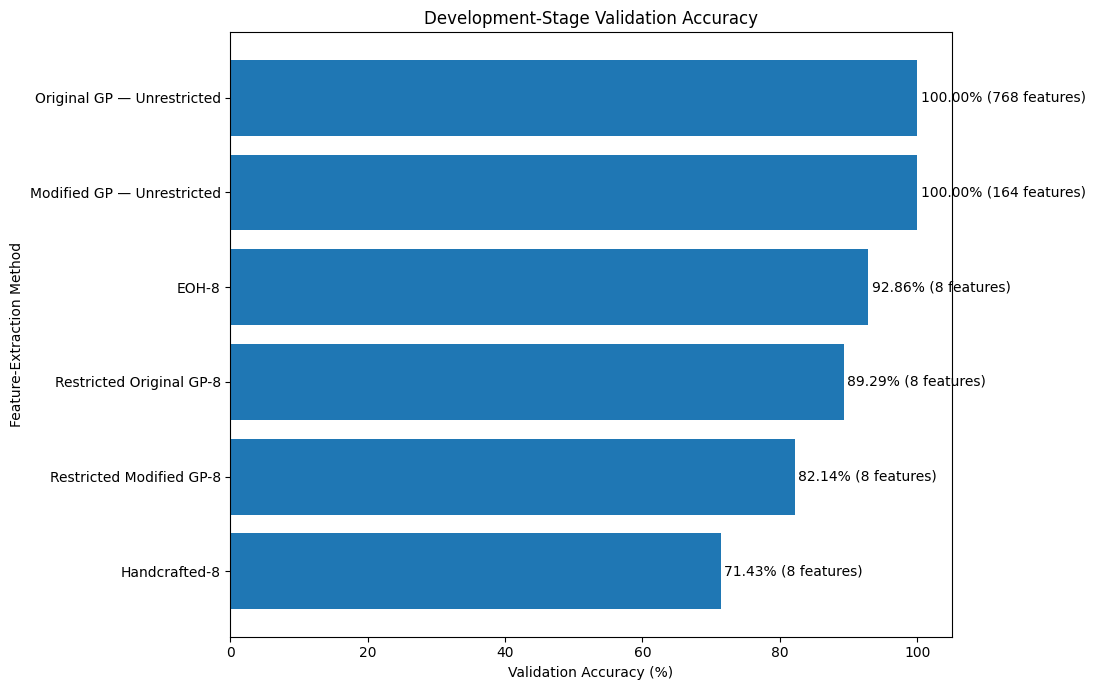

In [ ]:
# -------------------------------------------------------
# Development-stage validation accuracy chart
# -------------------------------------------------------

accuracy_plot_data = (
    development_comparison
    .sort_values(
        by="validation_accuracy_percent",
        ascending=True,
    )
)

figure, axis = plt.subplots(
    figsize=(11, 7)
)

bars = axis.barh(
    accuracy_plot_data["method"],
    accuracy_plot_data[
        "validation_accuracy_percent"
    ],
)

axis.set_xlabel(
    "Validation Accuracy (%)"
)

axis.set_ylabel(
    "Feature-Extraction Method"
)

axis.set_title(
    "Development-Stage Validation Accuracy"
)

axis.set_xlim(
    0,
    105,
)

for bar, (_, row) in zip(
    bars,
    accuracy_plot_data.iterrows(),
):
    axis.text(
        row["validation_accuracy_percent"] + 0.5,
        bar.get_y() + bar.get_height() / 2,
        (
            f"{row['validation_accuracy_percent']:.2f}% "
            f"({int(row['feature_dimension'])} features)"
        ),
        va="center",
    )

plt.tight_layout()
plt.show()

In [59]:
dimension_controlled_comparison = (
    development_comparison[
        development_comparison["comparison_group"]
        == "dimension_controlled"
    ]
    .copy()
    .sort_values(
        by="validation_accuracy_percent",
        ascending=False,
    )
    .reset_index(drop=True)
)

dimension_controlled_comparison

,method,comparison_group,evaluation_pipeline,feature_dimension,validation_accuracy,validation_accuracy_percent,classifier,training_time_seconds,feature_extraction_time_seconds,classifier_training_time_seconds,test_evaluated
0,EOH-8,dimension_controlled,common_benchmark_pipeline,8,0.928571,92.857143,"SVC(kernel='linear', random_state=42)",NaN,NaN,0.003813,False
1,Restricted Original GP-8,dimension_controlled,restricted_gp_internal_pipeline,8,0.892900,89.290000,SVM,673.695712,NaN,NaN,False
2,Restricted Modified GP-8,dimension_controlled,restricted_modified_gp_internal_pipeline,8,0.821400,82.140000,SVM,1100.703744,NaN,NaN,False
3,Handcrafted-8,dimension_controlled,Not recorded,8,0.714286,71.428571,"SVC(kernel='linear', random_state=42)",NaN,NaN,0.001793,False


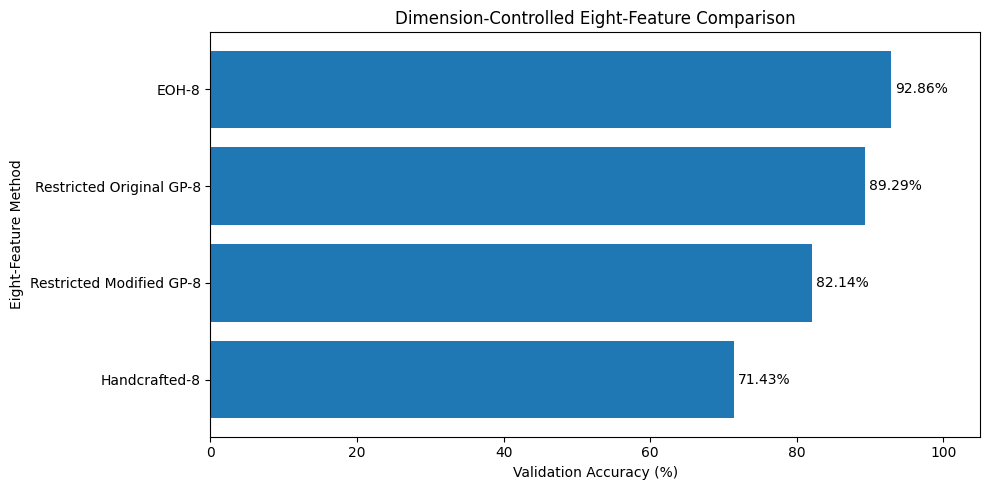

In [62]:
# ------------------------------------------------------------
# Dimension-controlled validation comparison
# ------------------------------------------------------------

dimension_controlled_plot_data = (
    dimension_controlled_comparison
    .sort_values(
        by="validation_accuracy_percent",
        ascending=True,
    )
)

figure, axis = plt.subplots(
    figsize=(10, 5)
)

bars = axis.barh(
    dimension_controlled_plot_data["method"],
    dimension_controlled_plot_data[
        "validation_accuracy_percent"
    ],
)

axis.set_xlabel(
    "Validation Accuracy (%)"
)

axis.set_ylabel(
    "Eight-Feature Method"
)

axis.set_title(
    "Dimension-Controlled Eight-Feature Comparison"
)

axis.set_xlim(
    0,
    105,
)

for bar, (_, row) in zip(
    bars,
    dimension_controlled_plot_data.iterrows(),
):
    axis.text(
        row["validation_accuracy_percent"] + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{row["validation_accuracy_percent"]:.2f}%',
        va="center",
    )

plt.tight_layout()
plt.show()

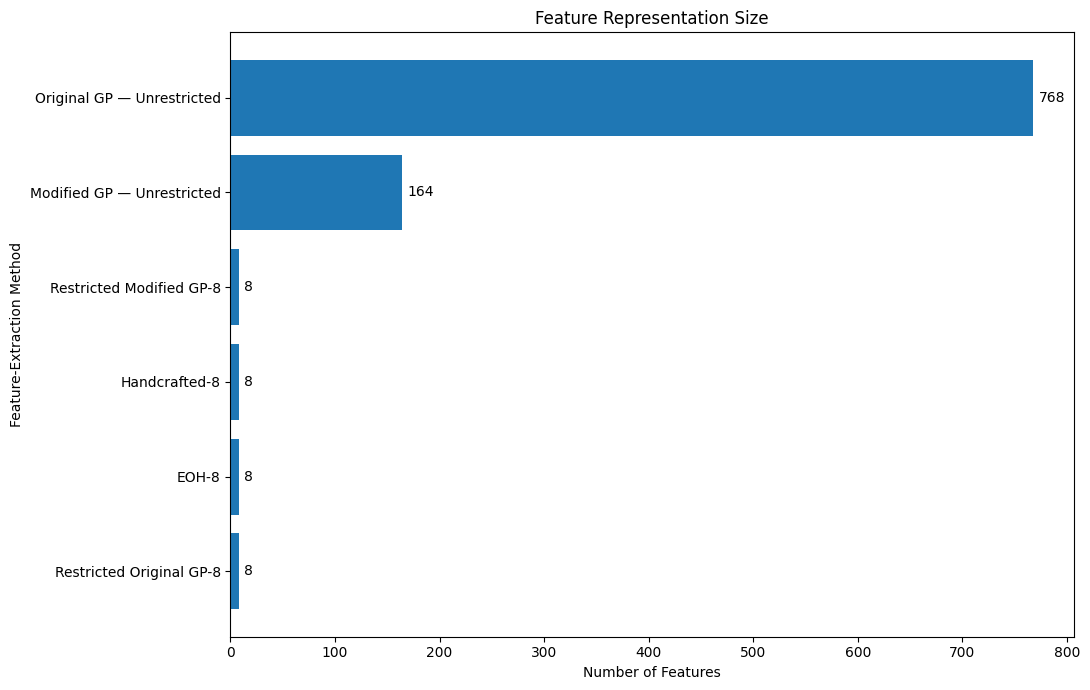

In [63]:
# -------------------------------------------------------
# Feature representation size
# -------------------------------------------------------

dimension_plot_data = (
    development_comparison
    .sort_values(
        by="feature_dimension",
        ascending=True,
    )
)

figure, axis = plt.subplots(
    figsize=(11, 7)
)

bars = axis.barh(
    dimension_plot_data["method"],
    dimension_plot_data[
        "feature_dimension"
    ],
)

axis.set_xlabel(
    "Number of Features"
)

axis.set_ylabel(
    "Feature-Extraction Method"
)

axis.set_title(
    "Feature Representation Size"
)

for bar, (_, row) in zip(
    bars,
    dimension_plot_data.iterrows(),
):
    axis.text(
        row["feature_dimension"] + 5,
        bar.get_y() + bar.get_height() / 2,
        str(int(row["feature_dimension"])),
        va="center",
    )

plt.tight_layout()
plt.show()

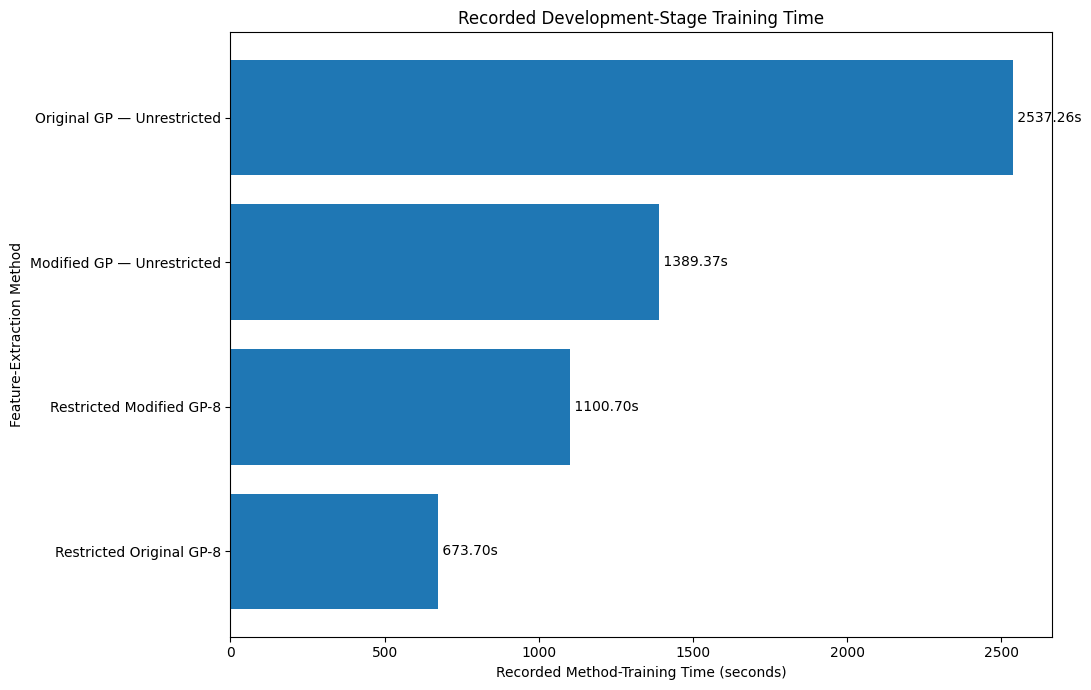

In [ ]:
# -------------------------------------------------------
# Recorded method-training time comparison
# -------------------------------------------------------

training_time_plot_data = (
    development_comparison[
        development_comparison[
            "training_time_seconds"
        ].notna()
    ]
    .copy()
    .sort_values(
        by="training_time_seconds",
        ascending=True,
    )
)

if training_time_plot_data.empty:

    print(
        "No comparable method-training times were recorded."
    )

else:

    figure, axis = plt.subplots(
        figsize=(11, 7)
    )

    bars = axis.barh(
        training_time_plot_data["method"],
        training_time_plot_data[
            "training_time_seconds"
        ],
    )

    axis.set_xlabel(
        "Recorded Method-Training Time (seconds)"
    )

    axis.set_ylabel(
        "Feature-Extraction Method"
    )

    axis.set_title(
        "Recorded Development-Stage Training Time"
    )

    for bar, (_, row) in zip(
        bars,
        training_time_plot_data.iterrows(),
    ):
        axis.text(
            row["training_time_seconds"],
            bar.get_y() + bar.get_height() / 2,
            f" {row['training_time_seconds']:.2f}s",
            va="center",
        )

    plt.tight_layout()
    plt.show()

In [64]:
# -------------------------------------------------------
# Ranking and development-stage integrity checks
# -------------------------------------------------------

development_ranking = (
    development_comparison[
        [
            "method",
            "comparison_group",
            "feature_dimension",
            "validation_accuracy_percent",
            "classifier",
        ]
    ]
    .copy()
)

development_ranking.index = (
    development_ranking.index + 1
)

development_ranking.index.name = "rank"

if development_comparison[
    "test_evaluated"
].any():
    raise RuntimeError(
        "At least one development-stage method reports "
        "that the held-out test set was evaluated."
    )

print("=" * 70)
print("Development-stage benchmark status")
print("=" * 70)
print(
    f"Methods compared             : "
    f"{len(development_comparison)}"
)
print(
    f"Dimension-controlled methods : "
    f"{len(dimension_controlled_comparison)}"
)
print(
    f"Unrestricted references      : "
    f"{len(unrestricted_reference_comparison)}"
)
print(
    "Held-out test evaluations   : 0"
)
print("=" * 70)
print(
    "PASS: development comparison completed "
    "without using the held-out test set."
)

development_ranking

Development-stage benchmark status
Methods compared             : 6
Dimension-controlled methods : 4
Unrestricted references      : 2
Held-out test evaluations   : 0
PASS: development comparison completed without using the held-out test set.


,method,comparison_group,feature_dimension,validation_accuracy_percent,classifier
rank,,,,,
1,Modified GP — Unrestricted,unrestricted_reference,164,100.000000,SVM
2,Original GP — Unrestricted,unrestricted_reference,768,100.000000,SVM
3,EOH-8,dimension_controlled,8,92.857143,"SVC(kernel='linear', random_state=42)"
4,Restricted Original GP-8,dimension_controlled,8,89.290000,SVM
5,Restricted Modified GP-8,dimension_controlled,8,82.140000,SVM
6,Handcrafted-8,dimension_controlled,8,71.428571,"SVC(kernel='linear', random_state=42)"


## Interpretation

The primary scientific comparison is the dimension-controlled table containing
Handcrafted-8, Restricted Original GP-8, Restricted Modified GP-8 and EOH-8.

Each of these methods returns exactly eight features. The unrestricted Original
GP and Modified GP results remain useful references, but they should not be
interpreted as directly equivalent because they use larger feature
representations and their own internal evaluation pipelines.

The development-stage results are based on a single fixed training and
validation split. They provide preliminary evidence rather than a final estimate
of generalisation performance.

The held-out test partition remains locked. It will be evaluated only after the
robustness experiments and final method-selection procedure have been completed.